compute band power per channel for Δ/θ/α/β/γ,

interpolate channel values onto a 64×64 scalp grid using your {channel_locs},

stack bands to produce (N, 5, 64, 64) images,

cache images to disk,

train a pretrained ResNet-18 adapted to 5-channel input with transfer learning,

apply safe augmentations for scalp maps (no left-right flips),

evaluate with stratified cross-subject split (LOSO / k-fold by subject),

produce occlusion maps and a Grad-CAM-style explanation for per-band importance.

In [1]:
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.interpolate import griddata
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from tqdm import tqdm

## Load and Clean EEG CSVs into the requested DataFrames
We load the six CSVs available in `data/` and create the cleaned DataFrames with the expected variable names.

In [2]:
import pandas as pd
import numpy as np

file_serie1 = 'data/skytt1serie1.csv'  # Replace it with your file path
file_serie2 = 'data/skytt1serie2.csv'
file_serie3 = 'data/skytt1serie3.csv'

file_serie11 = 'data/skytt2serie1.csv'  # Replace it with your file path
file_serie21 = 'data/skytt2serie2.csv'
file_serie31 = 'data/skytt2serie3.csv'

In [3]:
raw_serie1 = pd.read_csv(file_serie1, header=None, low_memory=False)  # For Serie 1
raw_serie2 = pd.read_csv(file_serie2, header=None, low_memory=False)  # For Serie 2
raw_serie3 = pd.read_csv(file_serie3, header=None, low_memory=False) # For Serie 3

raw_serie11 = pd.read_csv(file_serie11, header=None, low_memory=False)  # For Serie 11
raw_serie21 = pd.read_csv(file_serie21, header=None, low_memory=False)  # For Serie 21
raw_serie31 = pd.read_csv(file_serie31, header=None, low_memory=False) # For Serie 31

In [4]:
# Drop columns 41 and 42 (0-based index: 40 and 41)
raw_serie1 = raw_serie1.drop(columns=[41, 42])

In [5]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie1.iloc[0]  # First row: FFT Bands
header2 = raw_serie1.iloc[1]  # Second row: Frequencies
header3 = raw_serie1.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # First column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie1 = raw_serie1.iloc[3:].copy()  # Drop the first three rows
clean_serie1.columns = new_columns      # Assign the new combined header
clean_serie1.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie1.columns[1:]:  # Skip 'Time'
    clean_serie1[col] = pd.to_numeric(clean_serie1[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie1['Time'] = (
    clean_serie1['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie1['Time'] = pd.to_datetime(clean_serie1['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie1.columns = clean_serie1.columns.str.replace("'", "")
# Final check
print(clean_serie1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26537 entries, 0 to 26536
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      26537 non-null  datetime64[ns]
 1   Delta_F3  26537 non-null  float64       
 2   Delta_Fz  26537 non-null  int64         
 3   Delta_F4  26537 non-null  float64       
 4   Delta_C3  26537 non-null  float64       
 5   Delta_C4  26537 non-null  float64       
 6   Delta_Pz  26537 non-null  float64       
 7   Delta_O1  26537 non-null  float64       
 8   Delta_O2  26537 non-null  float64       
 9   Theta_F3  26537 non-null  float64       
 10  Theta_Fz  26537 non-null  int64         
 11  Theta_F4  26537 non-null  float64       
 12  Theta_C3  26537 non-null  float64       
 13  Theta_C4  26537 non-null  float64       
 14  Theta_Pz  26537 non-null  float64       
 15  Theta_O1  26537 non-null  float64       
 16  Theta_O2  26537 non-null  float64       
 17  Alpha_F3  26

In [6]:
clean_serie1.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 13:30:14.835,1.35,0,1.15,2.45,1.31,1.16,1.33,1.34,2.22,...,10.64,10.44,0.15,0,0.17,0.37,0.15,0.13,0.17,0.16
1,2023-03-31 13:30:14.847,1.38,0,1.14,2.45,1.35,1.19,1.36,1.37,2.21,...,10.66,10.47,0.14,0,0.16,0.36,0.15,0.12,0.16,0.16
2,2023-03-31 13:30:14.854,1.40,0,1.13,2.44,1.38,1.23,1.38,1.40,2.17,...,10.71,10.50,0.13,0,0.15,0.35,0.14,0.12,0.14,0.15
3,2023-03-31 13:30:14.877,1.42,0,1.13,2.45,1.40,1.25,1.39,1.41,2.14,...,10.76,10.55,0.12,0,0.14,0.35,0.13,0.12,0.14,0.14
4,2023-03-31 13:30:14.892,1.44,0,1.13,2.46,1.41,1.27,1.40,1.42,2.11,...,10.80,10.60,0.12,0,0.14,0.34,0.12,0.13,0.14,0.14
5,2023-03-31 13:30:14.915,1.46,0,1.12,2.49,1.43,1.29,1.42,1.43,2.09,...,10.84,10.65,0.12,0,0.14,0.34,0.12,0.12,0.14,0.13
6,2023-03-31 13:30:14.928,1.44,0,1.11,2.52,1.44,1.31,1.41,1.44,2.03,...,10.87,10.69,0.12,0,0.14,0.33,0.12,0.12,0.13,0.12
7,2023-03-31 13:30:14.943,1.43,0,1.10,2.51,1.43,1.30,1.41,1.43,1.98,...,10.89,10.72,0.13,0,0.13,0.33,0.12,0.12,0.13,0.12
8,2023-03-31 13:30:14.960,1.37,0,1.05,2.50,1.42,1.29,1.35,1.43,1.92,...,10.93,10.74,0.13,0,0.14,0.32,0.12,0.13,0.13,0.12
9,2023-03-31 13:30:14.977,1.32,0,1.01,2.47,1.36,1.24,1.30,1.39,1.99,...,10.96,10.77,0.14,0,0.14,0.33,0.11,0.12,0.14,0.12


In [7]:
# Step 2: Extract the three header rows for Series 2
header1 = raw_serie2.iloc[0]  # First row: FFT Bands
header2 = raw_serie2.iloc[1]  # Second row: Frequencies
header3 = raw_serie2.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # The first column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie2 = raw_serie2.iloc[3:].copy()  # Drop the first three rows
clean_serie2.columns = new_columns      # Assign the new combined header
clean_serie2.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie2.columns[1:]:  # Skip 'Time'
    clean_serie2[col] = pd.to_numeric(clean_serie2[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie2['Time'] = (
    clean_serie2['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie2['Time'] = pd.to_datetime(clean_serie2['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie2.columns = clean_serie2.columns.str.replace("'", "")
# Final check
print(clean_serie2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24249 entries, 0 to 24248
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      24249 non-null  datetime64[ns]
 1   Delta_F3  24249 non-null  float64       
 2   Delta_Fz  24249 non-null  int64         
 3   Delta_F4  24249 non-null  float64       
 4   Delta_C3  24249 non-null  float64       
 5   Delta_C4  24249 non-null  float64       
 6   Delta_Pz  24249 non-null  float64       
 7   Delta_O1  24249 non-null  float64       
 8   Delta_O2  24249 non-null  float64       
 9   Theta_F3  24249 non-null  float64       
 10  Theta_Fz  24249 non-null  int64         
 11  Theta_F4  24249 non-null  float64       
 12  Theta_C3  24249 non-null  float64       
 13  Theta_C4  24249 non-null  float64       
 14  Theta_Pz  24249 non-null  float64       
 15  Theta_O1  24249 non-null  float64       
 16  Theta_O2  24249 non-null  float64       
 17  Alpha_F3  24

In [8]:
clean_serie2.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 13:38:54.841,1.94,0,2.89,6.95,2.74,2.52,2.81,2.28,18.60,...,5.99,7.35,0.29,0,0.21,1.46,0.20,0.19,0.19,0.22
1,2023-03-31 13:38:54.856,1.84,0,2.79,6.86,2.67,2.45,2.72,2.19,18.71,...,6.08,7.47,0.28,0,0.20,1.44,0.21,0.18,0.18,0.23
2,2023-03-31 13:38:54.867,1.75,0,2.70,6.70,2.55,2.34,2.63,2.08,18.81,...,6.16,7.62,0.27,0,0.20,1.38,0.20,0.18,0.18,0.22
3,2023-03-31 13:38:54.881,1.66,0,2.61,6.55,2.44,2.24,2.54,1.98,18.90,...,6.24,7.75,0.27,0,0.19,1.33,0.19,0.18,0.17,0.21
4,2023-03-31 13:38:54.899,1.63,0,2.60,6.42,2.33,2.14,2.52,1.89,18.95,...,6.30,7.88,0.25,0,0.20,1.29,0.19,0.17,0.18,0.20
5,2023-03-31 13:38:54.915,1.60,0,2.59,6.38,2.32,2.09,2.51,1.88,19.01,...,6.37,7.99,0.25,0,0.21,1.28,0.19,0.17,0.18,0.21
6,2023-03-31 13:38:54.932,1.60,0,2.60,6.34,2.30,2.04,2.53,1.88,19.02,...,6.38,8.10,0.25,0,0.20,1.27,0.20,0.17,0.18,0.21
7,2023-03-31 13:38:54.950,1.61,0,2.61,6.16,2.31,2.03,2.56,1.89,19.03,...,6.40,8.17,0.25,0,0.20,1.27,0.20,0.18,0.19,0.21
8,2023-03-31 13:38:54.964,1.61,0,2.62,6.00,2.33,2.01,2.58,1.89,19.04,...,6.41,8.23,0.25,0,0.20,1.27,0.19,0.18,0.19,0.20
9,2023-03-31 13:38:54.981,1.59,0,2.63,5.85,2.34,2.00,2.61,1.90,19.03,...,6.35,8.29,0.25,0,0.20,1.26,0.19,0.18,0.20,0.20


In [9]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie3.iloc[0]  # First row: FFT Bands
header2 = raw_serie3.iloc[1]  # Second row: Frequencies
header3 = raw_serie3.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # The first column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie3 = raw_serie3.iloc[3:].copy()  # Drop the first three rows
clean_serie3.columns = new_columns      # Assign the new combined header
clean_serie3.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie3.columns[1:]:  # Skip 'Time'
    clean_serie3[col] = pd.to_numeric(clean_serie3[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie3['Time'] = (
    clean_serie3['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie3['Time'] = pd.to_datetime(clean_serie3['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie3.columns = clean_serie3.columns.str.replace("'", "")
# Final check
print(clean_serie3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17688 entries, 0 to 17687
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      17688 non-null  datetime64[ns]
 1   Delta_F3  17688 non-null  float64       
 2   Delta_Fz  17688 non-null  float64       
 3   Delta_F4  17688 non-null  float64       
 4   Delta_C3  17688 non-null  float64       
 5   Delta_C4  17688 non-null  float64       
 6   Delta_Pz  17688 non-null  float64       
 7   Delta_O1  17688 non-null  float64       
 8   Delta_O2  17688 non-null  float64       
 9   Theta_F3  17688 non-null  float64       
 10  Theta_Fz  17688 non-null  float64       
 11  Theta_F4  17688 non-null  float64       
 12  Theta_C3  17688 non-null  float64       
 13  Theta_C4  17688 non-null  float64       
 14  Theta_Pz  17688 non-null  float64       
 15  Theta_O1  17688 non-null  float64       
 16  Theta_O2  17688 non-null  float64       
 17  Alpha_F3  17

In [10]:
clean_serie3.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 14:55:39.631,1.13,0.81,1.24,1.28,2.96,11.60,3.33,2.28,4.57,...,6.93,10.47,0.43,0.22,0.29,0.37,0.41,0.55,0.52,0.35
1,2023-03-31 14:55:39.648,1.08,0.76,1.33,1.31,2.98,11.68,3.18,2.31,4.53,...,7.07,10.34,0.41,0.21,0.28,0.37,0.40,0.56,0.52,0.36
2,2023-03-31 14:55:39.660,1.03,0.72,1.41,1.38,3.14,11.53,3.05,2.39,4.49,...,7.21,10.19,0.40,0.21,0.27,0.35,0.40,0.56,0.52,0.34
3,2023-03-31 14:55:39.674,1.06,0.69,1.37,1.45,3.30,11.40,2.87,2.47,4.40,...,7.31,10.06,0.39,0.20,0.28,0.34,0.39,0.55,0.53,0.33
4,2023-03-31 14:55:39.692,1.09,0.66,1.34,1.47,3.44,11.37,2.72,2.46,4.32,...,7.41,9.96,0.37,0.20,0.29,0.33,0.39,0.53,0.54,0.32
5,2023-03-31 14:55:39.708,1.08,0.63,1.35,1.48,3.57,11.34,2.76,2.44,4.24,...,7.38,9.87,0.37,0.19,0.28,0.33,0.40,0.52,0.54,0.32
6,2023-03-31 14:55:39.725,1.06,0.63,1.37,1.49,3.90,11.25,2.79,2.43,4.17,...,7.34,9.84,0.38,0.19,0.27,0.34,0.41,0.48,0.54,0.32
7,2023-03-31 14:55:39.743,1.03,0.64,1.29,1.49,4.20,11.16,2.81,2.41,4.15,...,7.19,9.82,0.37,0.20,0.29,0.35,0.43,0.45,0.54,0.33
8,2023-03-31 14:55:39.760,1.00,0.63,1.22,1.42,4.56,11.27,2.82,2.34,4.13,...,7.05,9.92,0.36,0.19,0.30,0.40,0.42,0.48,0.53,0.34
9,2023-03-31 14:55:39.776,0.97,0.61,1.16,1.35,4.88,11.38,2.83,2.28,4.12,...,6.92,10.01,0.37,0.19,0.31,0.45,0.42,0.50,0.53,0.35


In [11]:
raw_serie11.sample(10)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
10645,'[14:06:48.717 31/03/2023]',0.49,1.78,1.08,0.33,0.25,0.34,0.9,0.67,1.9,...,4.22,3.47,0.26,0.75,0.25,0.19,0.08,0.17,0.45,0.18
12133,'[14:07:13.516 31/03/2023]',0.56,2.8,0.68,0.77,0.5,1.16,1.87,1.01,2.78,...,5.47,5.35,0.14,0.64,0.23,0.16,0.16,0.2,0.19,0.26
18440,'[14:08:58.627 31/03/2023]',0.18,0.62,0.18,0.23,0.21,0.24,0.27,0.22,0.94,...,4.92,4.12,0.1,0.17,0.1,0.11,0.08,0.12,0.14,0.12
3055,'[14:04:42.231 31/03/2023]',0.15,0.16,0.14,0.14,0.13,0.16,0.2,0.14,1.01,...,3.44,2.84,0.11,0.11,0.09,0.11,0.1,0.13,0.18,0.14
335,'[14:03:56.901 31/03/2023]',0.34,0.53,0.29,0.19,0.2,0.22,0.13,0.17,2.02,...,1.95,1.13,0.11,0.13,0.07,0.05,0.06,0.07,0.07,0.06
6736,'[14:05:43.574 31/03/2023]',0.29,0.85,0.34,0.2,0.21,0.27,0.39,0.18,2.22,...,5.14,4.96,0.1,0.25,0.09,0.1,0.09,0.13,0.18,0.14
621,'[14:04:01.669 31/03/2023]',0.94,2.6,0.99,0.41,0.48,0.58,0.55,0.35,5.94,...,3.86,2.76,0.3,0.56,0.14,0.12,0.11,0.13,0.29,0.13
12423,'[14:07:18.356 31/03/2023]',0.29,1.31,0.41,0.4,0.25,0.39,0.52,0.74,1.61,...,2.41,2.77,0.1,0.36,0.09,0.1,0.08,0.15,0.18,0.14
21960,'[14:09:57.283 31/03/2023]',0.43,2.83,0.54,0.31,0.34,0.33,0.38,0.94,3.41,...,3.13,1.69,0.14,1.26,0.19,0.1,0.09,0.12,0.13,0.23
6912,'[14:05:46.507 31/03/2023]',0.25,0.3,0.24,0.22,0.2,0.33,0.32,0.25,1.46,...,3.44,2.76,0.12,0.12,0.11,0.14,0.11,0.19,0.18,0.21


In [12]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie11.iloc[0]  # First row: FFT Bands
header2 = raw_serie11.iloc[1]  # Second row: Frequencies
header3 = raw_serie11.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # First column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie11 = raw_serie11.iloc[3:].copy()  # Drop the first three rows
clean_serie11.columns = new_columns      # Assign the new combined header
clean_serie11.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie11.columns[1:]:  # Skip 'Time'
    clean_serie11[col] = pd.to_numeric(clean_serie11[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie11['Time'] = (
    clean_serie11['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie11['Time'] = pd.to_datetime(clean_serie11['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie11.columns = clean_serie11.columns.str.replace("'", "")
# Final check
print(clean_serie11.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23393 entries, 0 to 23392
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      23393 non-null  datetime64[ns]
 1   Delta_F3  23393 non-null  float64       
 2   Delta_Fz  23393 non-null  float64       
 3   Delta_F4  23393 non-null  float64       
 4   Delta_C3  23393 non-null  float64       
 5   Delta_C4  23393 non-null  float64       
 6   Delta_Pz  23393 non-null  float64       
 7   Delta_O1  23393 non-null  float64       
 8   Delta_O2  23393 non-null  float64       
 9   Theta_F3  23393 non-null  float64       
 10  Theta_Fz  23393 non-null  float64       
 11  Theta_F4  23393 non-null  float64       
 12  Theta_C3  23393 non-null  float64       
 13  Theta_C4  23393 non-null  float64       
 14  Theta_Pz  23393 non-null  float64       
 15  Theta_O1  23393 non-null  float64       
 16  Theta_O2  23393 non-null  float64       
 17  Alpha_F3  23

In [13]:
clean_serie11.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 14:03:51.373,0.21,0.54,0.24,0.25,0.19,0.31,0.39,0.27,1.06,...,1.00,1.06,0.08,0.10,0.08,0.08,0.08,0.12,0.11,0.08
1,2023-03-31 14:03:51.391,0.22,0.53,0.24,0.26,0.19,0.32,0.39,0.28,1.02,...,0.99,1.03,0.08,0.10,0.07,0.08,0.08,0.11,0.10,0.07
2,2023-03-31 14:03:51.398,0.23,0.52,0.25,0.27,0.20,0.31,0.39,0.28,0.99,...,0.98,1.01,0.07,0.09,0.07,0.08,0.07,0.11,0.10,0.07
3,2023-03-31 14:03:51.419,0.24,0.51,0.25,0.27,0.20,0.31,0.39,0.28,0.95,...,0.97,0.99,0.07,0.09,0.07,0.07,0.07,0.10,0.10,0.07
4,2023-03-31 14:03:51.436,0.24,0.50,0.24,0.28,0.21,0.30,0.38,0.28,0.92,...,0.95,0.97,0.07,0.09,0.07,0.07,0.06,0.10,0.09,0.07
5,2023-03-31 14:03:51.453,0.24,0.49,0.24,0.28,0.21,0.30,0.38,0.27,0.90,...,0.94,0.94,0.07,0.09,0.07,0.07,0.06,0.10,0.09,0.07
6,2023-03-31 14:03:51.469,0.23,0.50,0.23,0.27,0.21,0.28,0.39,0.26,0.89,...,0.94,0.92,0.06,0.09,0.07,0.07,0.06,0.10,0.09,0.07
7,2023-03-31 14:03:51.486,0.21,0.49,0.22,0.26,0.19,0.28,0.39,0.26,0.88,...,0.94,0.90,0.06,0.09,0.07,0.07,0.06,0.09,0.09,0.07
8,2023-03-31 14:03:51.503,0.20,0.49,0.21,0.25,0.18,0.27,0.39,0.26,0.87,...,0.95,0.88,0.06,0.08,0.07,0.07,0.07,0.09,0.09,0.06
9,2023-03-31 14:03:51.519,0.19,0.50,0.21,0.24,0.19,0.26,0.38,0.25,0.86,...,0.96,0.86,0.06,0.08,0.07,0.07,0.06,0.09,0.09,0.06


In [14]:
raw_serie21.head(10)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,'FFT Bands',Delta,Delta,Delta,Delta,Delta,Delta,Delta,Delta,Theta,...,Beta,Beta,Gamma,Gamma,Gamma,Gamma,Gamma,Gamma,Gamma,Gamma
1,'Time and date','F3','Fz','F4','C3','C4','Pz','O1','O2','F3',...,'O1','O2','F3','Fz','F4','C3','C4','Pz','O1','O2'
2,'[hh:mm:ss.mmm dd/mm/yyyy]',Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,...,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude
3,[14:13:48.555 31/03/2023]',0.47,0.99,1.46,0.41,0.59,0.61,0.67,0.85,3.17,...,2.2,7.38,0.17,0.21,0.15,0.14,0.13,0.14,0.17,0.22
4,[14:13:48.571 31/03/2023]',0.47,1.01,1.36,0.4,0.58,0.61,0.65,0.85,3.2,...,2.18,7.48,0.16,0.2,0.16,0.13,0.14,0.15,0.17,0.21
5,'[14:13:48.585 31/03/2023]',0.47,0.96,1.27,0.39,0.58,0.59,0.67,0.82,3.22,...,2.16,7.54,0.15,0.21,0.17,0.14,0.13,0.14,0.17,0.21
6,'[14:13:48.600 31/03/2023]',0.47,0.92,1.18,0.38,0.58,0.58,0.69,0.8,3.25,...,2.15,7.6,0.16,0.22,0.18,0.14,0.13,0.13,0.17,0.2
7,'[14:13:48.617 31/03/2023]',0.47,0.88,1.11,0.37,0.59,0.57,0.7,0.77,3.29,...,2.1,7.66,0.17,0.22,0.18,0.15,0.12,0.13,0.17,0.2
8,'[14:13:48.633 31/03/2023]',0.47,0.84,1.14,0.36,0.59,0.59,0.72,0.76,3.33,...,2.08,7.69,0.17,0.22,0.18,0.14,0.12,0.13,0.17,0.2
9,'[14:13:48.651 31/03/2023]',0.45,0.83,1.12,0.34,0.58,0.58,0.74,0.78,3.39,...,2.05,7.67,0.17,0.21,0.18,0.14,0.12,0.13,0.17,0.19


In [15]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie21.iloc[0]  # First row: FFT Bands
header2 = raw_serie21.iloc[1]  # Second row: Frequencies
header3 = raw_serie21.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # The first column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie21 = raw_serie21.iloc[3:].copy()  # Drop the first three rows
clean_serie21.columns = new_columns      # Assign the new combined header
clean_serie21.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie21.columns[1:]:  # Skip 'Time'
    clean_serie21[col] = pd.to_numeric(clean_serie21[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie21['Time'] = (
    clean_serie21['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie21['Time'] = pd.to_datetime(clean_serie21['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie21.columns = clean_serie21.columns.str.replace("'", "")
# Final check
print(clean_serie21.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25105 entries, 0 to 25104
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      25105 non-null  datetime64[ns]
 1   Delta_F3  25105 non-null  float64       
 2   Delta_Fz  25105 non-null  float64       
 3   Delta_F4  25105 non-null  float64       
 4   Delta_C3  25105 non-null  float64       
 5   Delta_C4  25105 non-null  float64       
 6   Delta_Pz  25105 non-null  float64       
 7   Delta_O1  25105 non-null  float64       
 8   Delta_O2  25105 non-null  float64       
 9   Theta_F3  25105 non-null  float64       
 10  Theta_Fz  25105 non-null  float64       
 11  Theta_F4  25105 non-null  float64       
 12  Theta_C3  25105 non-null  float64       
 13  Theta_C4  25105 non-null  float64       
 14  Theta_Pz  25105 non-null  float64       
 15  Theta_O1  25105 non-null  float64       
 16  Theta_O2  25105 non-null  float64       
 17  Alpha_F3  25

In [16]:
clean_serie21.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 14:13:48.555,0.47,0.99,1.46,0.41,0.59,0.61,0.67,0.85,3.17,...,2.20,7.38,0.17,0.21,0.15,0.14,0.13,0.14,0.17,0.22
1,2023-03-31 14:13:48.571,0.47,1.01,1.36,0.40,0.58,0.61,0.65,0.85,3.20,...,2.18,7.48,0.16,0.20,0.16,0.13,0.14,0.15,0.17,0.21
2,2023-03-31 14:13:48.585,0.47,0.96,1.27,0.39,0.58,0.59,0.67,0.82,3.22,...,2.16,7.54,0.15,0.21,0.17,0.14,0.13,0.14,0.17,0.21
3,2023-03-31 14:13:48.600,0.47,0.92,1.18,0.38,0.58,0.58,0.69,0.80,3.25,...,2.15,7.60,0.16,0.22,0.18,0.14,0.13,0.13,0.17,0.20
4,2023-03-31 14:13:48.617,0.47,0.88,1.11,0.37,0.59,0.57,0.70,0.77,3.29,...,2.10,7.66,0.17,0.22,0.18,0.15,0.12,0.13,0.17,0.20
5,2023-03-31 14:13:48.633,0.47,0.84,1.14,0.36,0.59,0.59,0.72,0.76,3.33,...,2.08,7.69,0.17,0.22,0.18,0.14,0.12,0.13,0.17,0.20
6,2023-03-31 14:13:48.651,0.45,0.83,1.12,0.34,0.58,0.58,0.74,0.78,3.39,...,2.05,7.67,0.17,0.21,0.18,0.14,0.12,0.13,0.17,0.19
7,2023-03-31 14:13:48.666,0.43,0.80,1.10,0.35,0.59,0.60,0.76,0.80,3.45,...,2.04,7.60,0.17,0.21,0.19,0.14,0.12,0.13,0.16,0.19
8,2023-03-31 14:13:48.683,0.44,0.78,1.15,0.36,0.60,0.62,0.74,0.81,3.49,...,1.98,7.53,0.17,0.20,0.19,0.14,0.12,0.13,0.18,0.19
9,2023-03-31 14:13:48.700,0.45,0.76,1.19,0.37,0.63,0.61,0.72,0.78,3.53,...,1.92,7.38,0.16,0.19,0.19,0.14,0.12,0.13,0.19,0.21


In [17]:
raw_serie31.sample(10)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
16487,'[15:13:36.074 31/03/2023]',0.34,0.39,0.28,0.28,0.23,0.28,0.32,0.25,0.72,...,9.54,8.01,0.13,0.1,0.11,0.13,0.11,0.19,0.21,0.2
3252,'[15:09:55.512 31/03/2023]',1.09,1.18,1.35,1.37,0.56,0.61,0.65,1.47,1.46,...,7.4,15.28,0.24,0.19,0.33,0.25,0.2,0.23,0.17,0.33
14999,'[15:13:11.277 31/03/2023]',0.21,0.22,0.18,0.15,0.22,0.19,0.23,0.24,0.67,...,3.16,2.1,0.13,0.13,0.11,0.14,0.14,0.18,0.19,0.19
13604,'[15:12:48.030 31/03/2023]',0.28,0.36,0.31,0.39,0.13,0.24,0.29,0.29,1.43,...,1.97,1.16,0.12,0.14,0.12,0.15,0.09,0.16,0.2,0.15
8817,'[15:11:28.254 31/03/2023]',0.61,0.88,0.88,0.91,0.43,0.92,0.6,1.9,0.88,...,9.11,9.59,0.09,0.28,0.24,0.28,0.13,0.25,0.14,0.45
3941,'[15:10:06.995 31/03/2023]',1.13,1.95,2.08,2.05,1,1.9,1.62,3.97,2.34,...,11.39,16.59,0.24,0.45,0.45,0.47,0.27,0.56,0.54,0.65
17856,'[15:13:58.889 31/03/2023]',0.33,0.24,0.25,0.29,0.18,0.25,0.25,0.23,0.93,...,4.39,3.1,0.16,0.16,0.14,0.17,0.13,0.17,0.19,0.19
13914,'[15:12:53.195 31/03/2023]',0.72,2.13,1.45,1.57,0.62,1.08,0.82,2.16,0.89,...,2.34,6.01,0.09,0.54,0.29,0.3,0.07,0.26,0.11,0.54
1467,'[15:09:25.767 31/03/2023]',0.38,0.41,0.36,0.37,0.28,0.26,0.31,0.37,1.28,...,6.21,3.92,0.12,0.13,0.11,0.13,0.12,0.11,0.13,0.14
4341,'[15:10:13.661 31/03/2023]',0.51,0.76,0.61,1.08,0.26,0.53,0.73,1.31,2.39,...,4.45,10.79,0.14,0.23,0.2,0.27,0.11,0.17,0.19,0.32


In [18]:
# Step 2: Extract the three header rows for Series 1
header1 = raw_serie31.iloc[0]  # First row: FFT Bands
header2 = raw_serie31.iloc[1]  # Second row: Frequencies
header3 = raw_serie31.iloc[2]  # Third row: Time format note (mainly first column)

# Step 3: Build new headers
new_columns = []

for col in range(len(header1)):
    if col == 0:
        # The first column is Time
        new_columns.append('Time')
    else:
        # Concatenate: Band + "_" + Frequency
        new_header = f"{header1[col]}_{header2[col]}"
        new_columns.append(new_header)

# Step 4: Assign the new headers & clean data
clean_serie31 = raw_serie31.iloc[3:].copy()  # Drop the first three rows
clean_serie31.columns = new_columns      # Assign the new combined header
clean_serie31.reset_index(drop=True, inplace=True)  # Reset index

# Step 5: Convert signal columns to numeric
for col in clean_serie31.columns[1:]:  # Skip 'Time'
    clean_serie31[col] = pd.to_numeric(clean_serie31[col], errors='coerce')

# Step 6: Clean the Time column (remove square brackets and strip spaces)
clean_serie31['Time'] = (
    clean_serie31['Time']
    .str.replace(r'[\[\]\']', '', regex=True)          # Remove [ ] and ' characters
    #.str.replace(r'\s*\d{2}/\d{2}/\d{4}', '', regex=True)  # Remove date (e.g., 31/03/2023)
    .str.strip()                                       # Remove any remaining whitespace
)

# Assuming your EEG dataframe is called eeg_df
clean_serie31['Time'] = pd.to_datetime(clean_serie31['Time'], format='%H:%M:%S.%f %d/%m/%Y')

# Removing ' from all column headers
clean_serie31.columns = clean_serie31.columns.str.replace("'", "")
# Final check
print(clean_serie31.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18638 entries, 0 to 18637
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Time      18638 non-null  datetime64[ns]
 1   Delta_F3  18638 non-null  float64       
 2   Delta_Fz  18638 non-null  float64       
 3   Delta_F4  18638 non-null  float64       
 4   Delta_C3  18638 non-null  float64       
 5   Delta_C4  18638 non-null  float64       
 6   Delta_Pz  18638 non-null  float64       
 7   Delta_O1  18638 non-null  float64       
 8   Delta_O2  18638 non-null  float64       
 9   Theta_F3  18638 non-null  float64       
 10  Theta_Fz  18638 non-null  float64       
 11  Theta_F4  18638 non-null  float64       
 12  Theta_C3  18638 non-null  float64       
 13  Theta_C4  18638 non-null  float64       
 14  Theta_Pz  18638 non-null  float64       
 15  Theta_O1  18638 non-null  float64       
 16  Theta_O2  18638 non-null  float64       
 17  Alpha_F3  18

In [19]:
clean_serie31.head(10)

,Time,Delta_F3,Delta_Fz,Delta_F4,Delta_C3,Delta_C4,Delta_Pz,Delta_O1,Delta_O2,Theta_F3,...,Beta_O1,Beta_O2,Gamma_F3,Gamma_Fz,Gamma_F4,Gamma_C3,Gamma_C4,Gamma_Pz,Gamma_O1,Gamma_O2
0,2023-03-31 15:09:01.370,3.06,4.40,5.70,4.17,2.22,4.88,7.27,7.83,10.68,...,19.96,17.69,0.31,1.21,1.56,1.43,0.65,1.41,1.76,1.27
1,2023-03-31 15:09:01.385,3.16,4.30,5.74,3.94,2.31,4.79,7.07,7.55,10.49,...,19.02,18.47,0.31,1.22,1.50,1.37,0.65,1.41,1.84,1.27
2,2023-03-31 15:09:01.401,3.24,4.35,5.77,3.84,2.30,4.82,6.88,7.45,10.31,...,18.69,19.48,0.31,1.20,1.44,1.37,0.64,1.38,1.92,1.26
3,2023-03-31 15:09:01.418,3.17,4.51,5.82,3.75,2.29,4.86,7.22,7.37,10.15,...,19.51,20.42,0.30,1.20,1.36,1.38,0.63,1.35,1.94,1.27
4,2023-03-31 15:09:01.436,3.10,4.33,5.87,3.59,2.19,4.94,7.54,7.33,10.00,...,20.27,21.40,0.31,1.17,1.30,1.37,0.60,1.33,1.95,1.27
5,2023-03-31 15:09:01.454,3.03,4.17,5.51,3.44,2.10,5.02,7.41,7.30,9.88,...,20.87,22.30,0.32,1.15,1.38,1.37,0.57,1.30,1.96,1.27
6,2023-03-31 15:09:01.468,2.97,4.12,5.18,3.41,1.99,5.37,7.28,7.05,9.77,...,21.98,23.16,0.35,1.11,1.45,1.32,0.54,1.37,1.97,1.20
7,2023-03-31 15:09:01.485,2.94,4.08,5.08,3.38,1.90,5.69,7.14,6.83,9.75,...,23.11,23.95,0.36,1.09,1.36,1.27,0.52,1.42,1.84,1.14
8,2023-03-31 15:09:01.501,2.91,4.03,4.98,3.26,1.95,5.98,7.00,6.84,9.73,...,24.15,24.58,0.38,1.11,1.29,1.34,0.52,1.39,1.72,1.12
9,2023-03-31 15:09:01.518,2.90,3.99,4.78,3.15,2.00,6.25,6.75,6.85,9.64,...,25.00,25.16,0.39,1.14,1.29,1.41,0.52,1.36,1.67,1.11


## Infer Sampling Frequency
We estimate Hz from the average delta of the Time column in `clean_serie1`.

In [20]:
def infer_sfreq(df: pd.DataFrame) -> float:
    if 'Time' not in df.columns:
        # Fallback assumption if no Time
        return 128.0
    ts = df['Time']
    if not np.issubdtype(ts.dtype, np.datetime64):
        return 128.0
    diffs = ts.diff().dropna().dt.total_seconds()
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return 128.0
    sf = 1.0 / diffs.mean()
    return float(np.round(sf, 2))

sfreq = infer_sfreq(clean_serie1)
print('Estimated sampling frequency:', sfreq, 'Hz')

Estimated sampling frequency: 60.01 Hz


Building Epochs

In [21]:
print(clean_serie1.columns.tolist())

['Time', 'Delta_F3', 'Delta_Fz', 'Delta_F4', 'Delta_C3', 'Delta_C4', 'Delta_Pz', 'Delta_O1', 'Delta_O2', 'Theta_F3', 'Theta_Fz', 'Theta_F4', 'Theta_C3', 'Theta_C4', 'Theta_Pz', 'Theta_O1', 'Theta_O2', 'Alpha_F3', 'Alpha_Fz', 'Alpha_F4', 'Alpha_C3', 'Alpha_C4', 'Alpha_Pz', 'Alpha_O1', 'Alpha_O2', 'Beta_F3', 'Beta_Fz', 'Beta_F4', 'Beta_C3', 'Beta_C4', 'Beta_Pz', 'Beta_O1', 'Beta_O2', 'Gamma_F3', 'Gamma_Fz', 'Gamma_F4', 'Gamma_C3', 'Gamma_C4', 'Gamma_Pz', 'Gamma_O1', 'Gamma_O2']


In [22]:
import mne
# Prepare for MNE: Extract EEG data & metadata
channel_names = clean_serie1.columns[1:].tolist()     # All columns except 'Time'
channel_types = ['eeg'] * len(channel_names)

# Transpose EEG data: shape must be [n_channels, n_samples]
eeg_valuesb1 = clean_serie1.iloc[:, 1:].T.values

# Create MNE Info and RawArray
infob1 = mne.create_info(ch_names=channel_names, sfreq=sfreq, ch_types=channel_types)
rawb1 = mne.io.RawArray(eeg_valuesb1, infob1)

# Extract the EEG data for the Delta frequency band (you can change this to any band)
columnsb1 = ["Beta_F3", "Beta_Fz", "Beta_F4", "Beta_C3", "Beta_C4",
           "Beta_Pz", "Beta_O1", "Beta_O2"]
eeg_datab1 = clean_serie1[columnsb1].values.T  # Transpose to (n_channels, n_timepoints)

# Create the info structure for MNE (specifying the channels and their type)
infob1 = mne.create_info(ch_names=[col.split("_")[1] for col in columnsb1], ch_types='eeg', sfreq=sfreq)

# Create the MNE Raw object
rawb1 = mne.io.RawArray(eeg_datab1, infob1)

# Let's create an Epochs object to allow for topomap plotting
# We'll use a 1 second interval for each epoch, assuming that the data is 1-second samples
eventsb1 = mne.make_fixed_length_events(rawb1, duration=1)  # Create events every 1 second
epochsb1 = mne.Epochs(rawb1, eventsb1, tmin=0, tmax=1, baseline=None, detrend=1)

# Check the unique event IDs in the raw events
print(epochsb1.event_id)

# Define the events: for example, let's assume you want to create events manually
eventsb1 = mne.make_fixed_length_events(rawb1, duration=1)  # Example, you may adjust based on your data

# Define the event dictionary: mapping event names to event IDs
event_dictb1 = {'button': 1, 'face': 2}

# You can check the events like this
print(eventsb1)

print(epochsb1)

print(epochsb1.info)

epochsb1.load_data()  #This will load the data for all epochs

print(f"Total epochs: {len(epochsb1)}")
print(f"Time points: {len(epochsb1.times)}")
print(f"Channel names: {epochsb1.ch_names}")
print(f"Data shape for epoch[1]: {epochsb1[1].get_data().shape}")  # Should be (1, n_channels, n_times)

Creating RawArray with float64 data, n_channels=40, n_times=26537
    Range : 0 ... 26536 =      0.000 ...   442.193 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=26537
    Range : 0 ... 26536 =      0.000 ...   442.193 secs
Ready.
Not setting metadata
442 matching events found
No baseline correction applied
0 projection items activated
{'1': 1}
[[    0     0     1]
 [   60     0     1]
 [  120     0     1]
 ...
 [26344     0     1]
 [26404     0     1]
 [26464     0     1]]
<Epochs | 442 events (good & bad), 0 – 1 s (baseline off), ~11 KiB, data not loaded,
 '1': 442>
<Info | 7 non-empty values
 bads: []
 ch_names: F3, Fz, F4, C3, C4, Pz, O1, O2
 chs: 8 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 30.0 Hz
 meas_date: unspecified
 nchan: 8
 projs: []
 sfreq: 60.0 Hz
>
Using data from preloaded Raw for 442 events and 61 original time points ...
0 bad epochs dropped
Total epochs: 442
Time points: 61
Channel names: ['F3', 'Fz', 'F4', 'C3', 'C4', 'Pz'

[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>, <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>, <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>, <DigPoint |    EEG #22 : (50.3, 87.4, 77.3) mm     : head frame>, <DigPoint |    EEG #40 : (-67.1, 23.4, 104.5) mm   : head frame>, <DigPoint |    EEG #44 : (65.3, 23.6, 103.7) mm    : head frame>, <DigPoint |    EEG #64 : (-1.7, -45.2, 126.7) mm   : head frame>, <DigPoint |    EEG #81 : (-31.6, -80.6, 54.8) mm   : head frame>, <DigPoint |    EEG #83 : (27.7, -80.5, 54.7) mm    : head frame>]


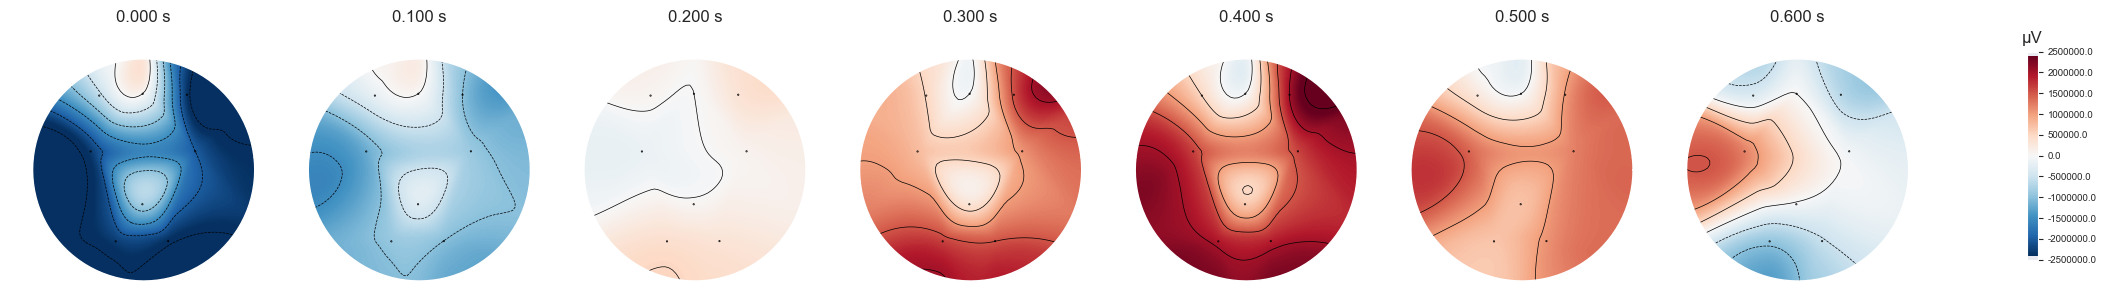

<Figure size 640x480 with 0 Axes>

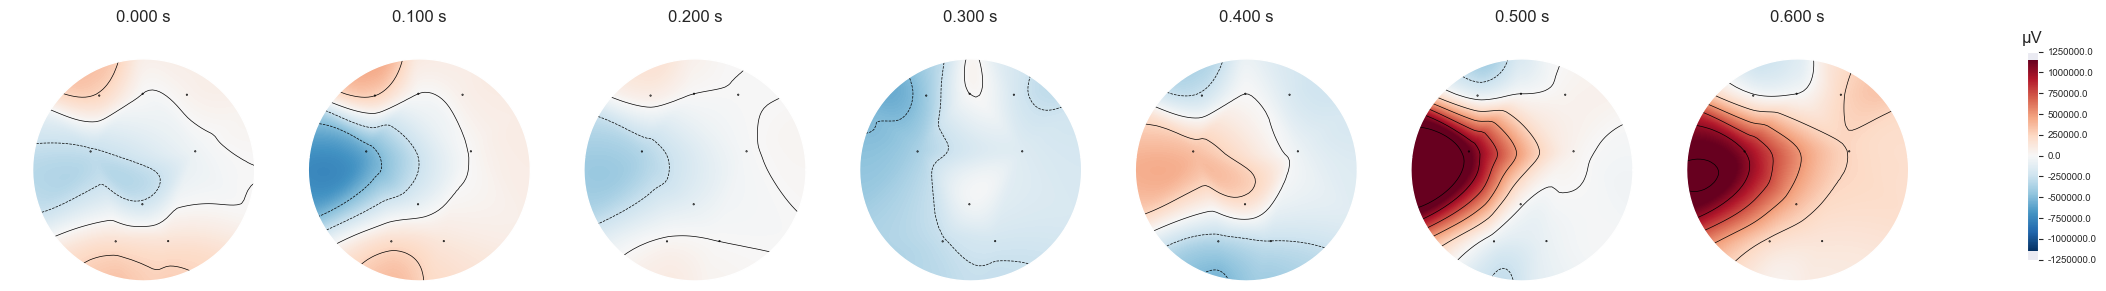

<Figure size 640x480 with 0 Axes>

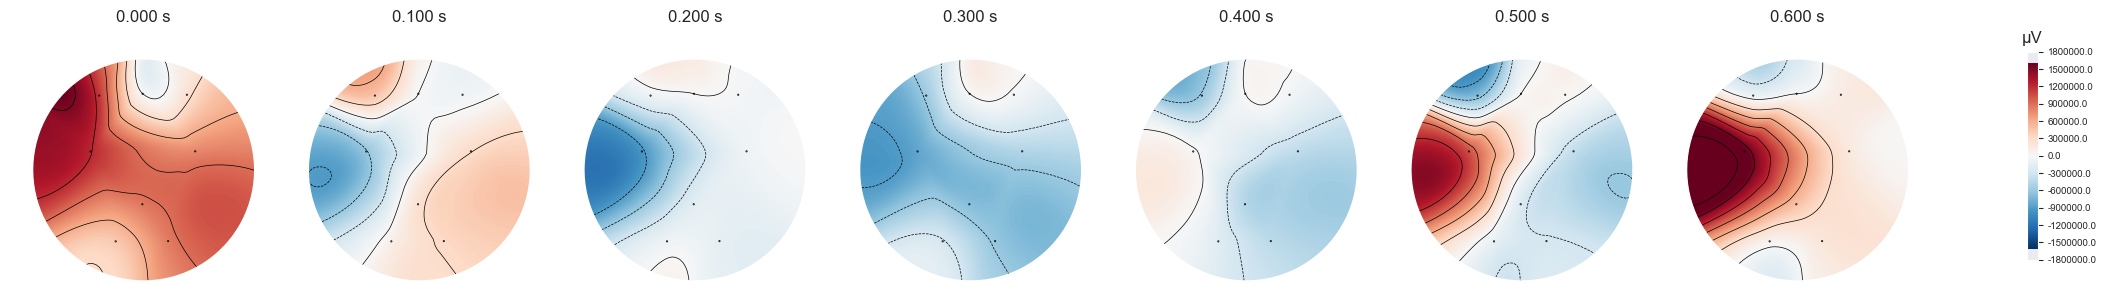

<Figure size 640x480 with 0 Axes>

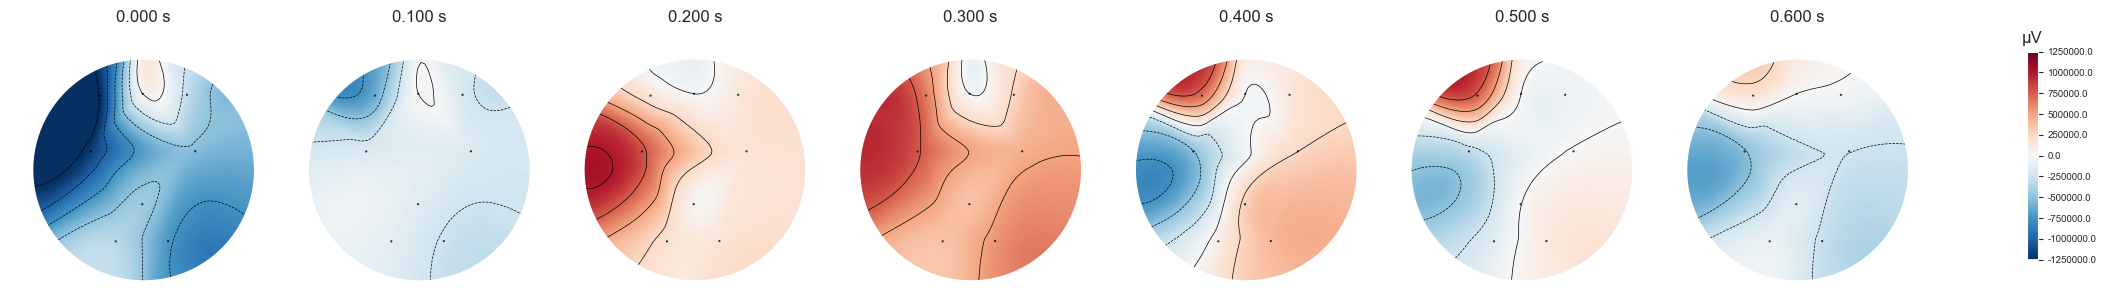

<Figure size 640x480 with 0 Axes>

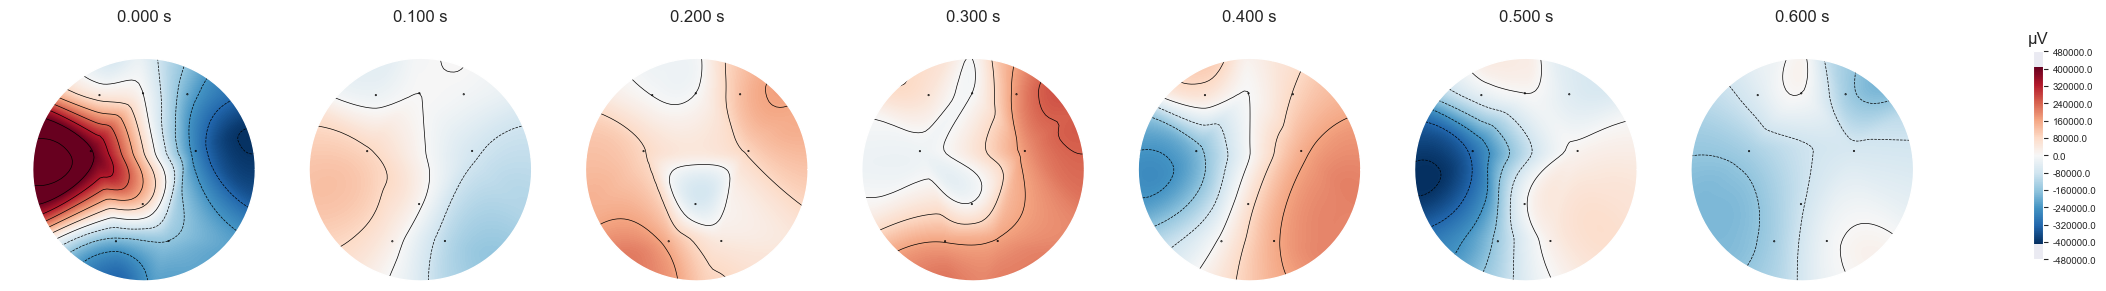

<Figure size 640x480 with 0 Axes>

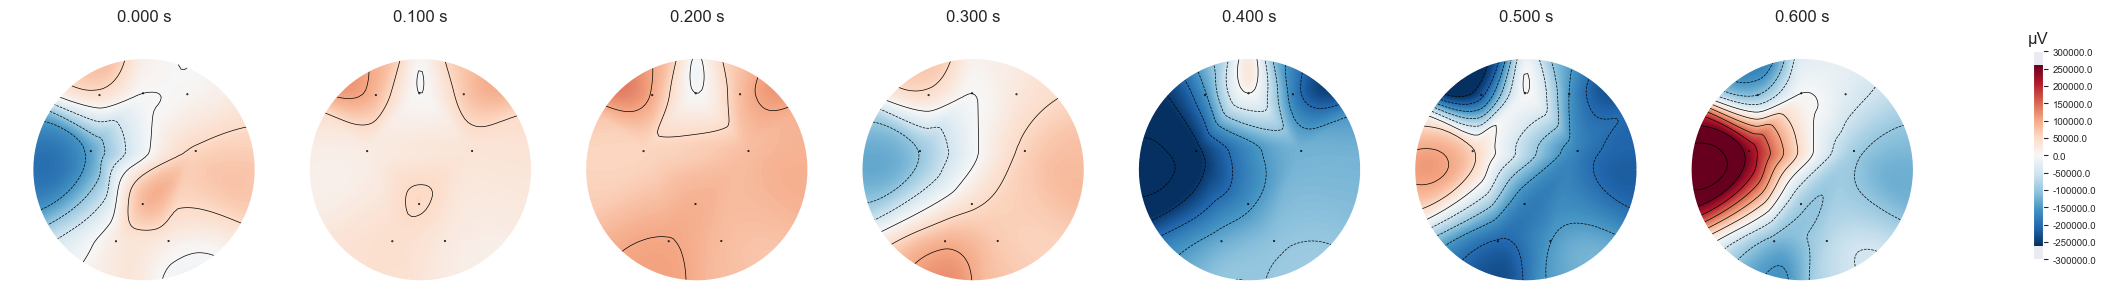

<Figure size 640x480 with 0 Axes>

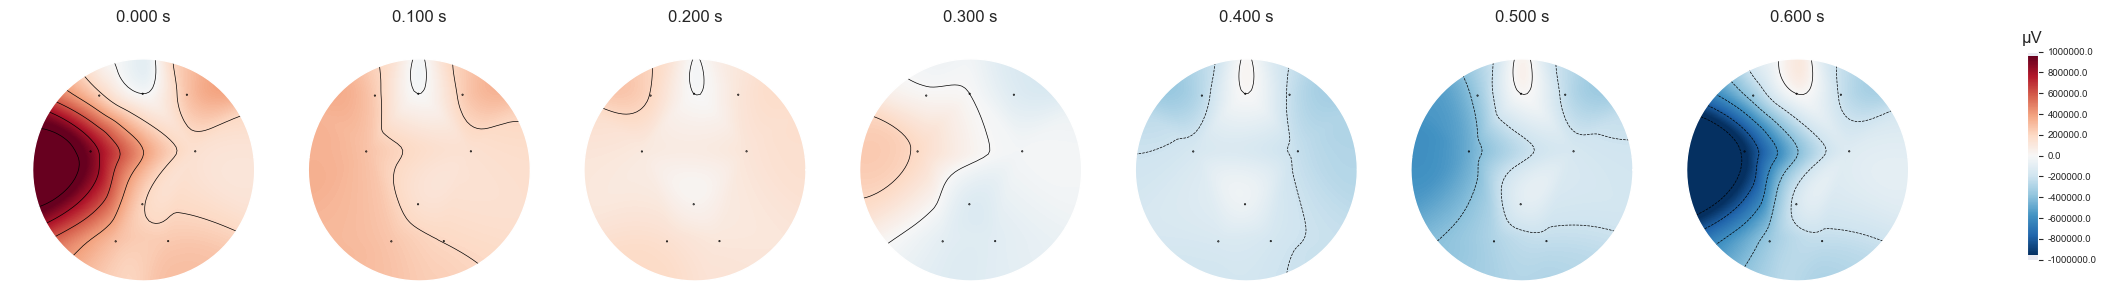

<Figure size 640x480 with 0 Axes>

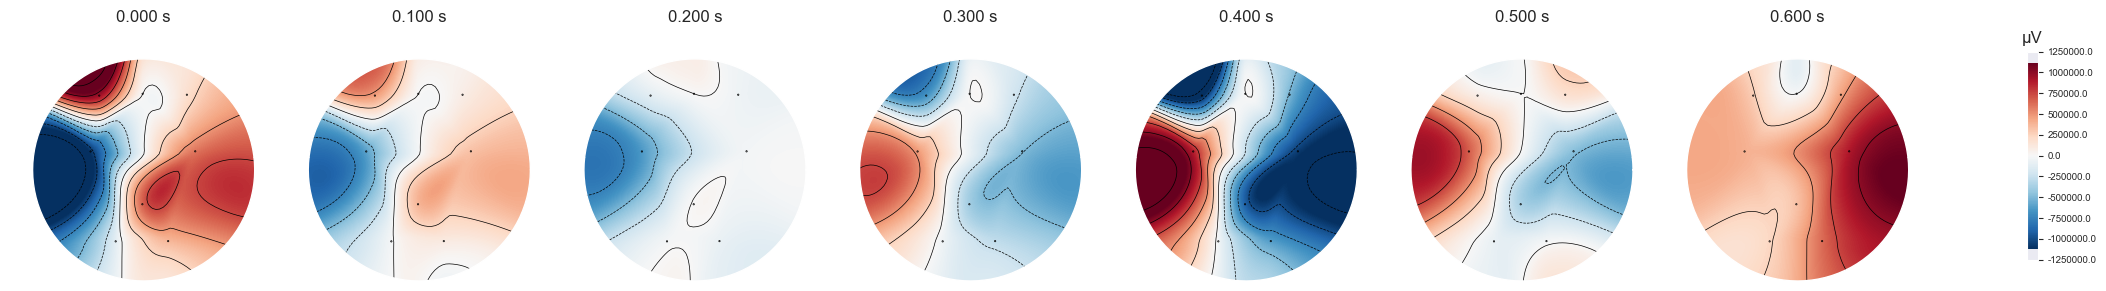

<Figure size 640x480 with 0 Axes>

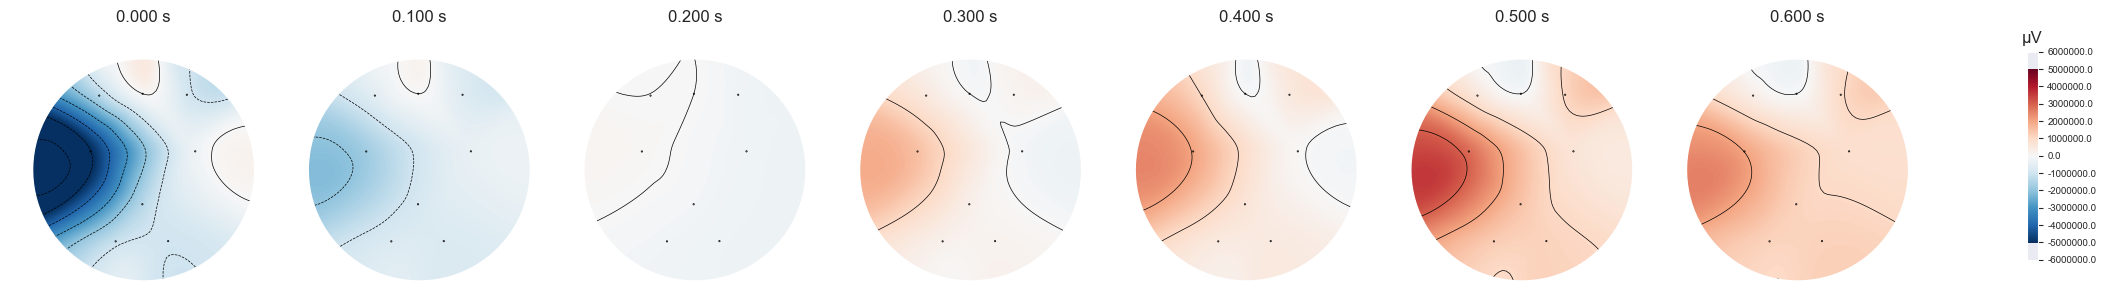

<Figure size 640x480 with 0 Axes>

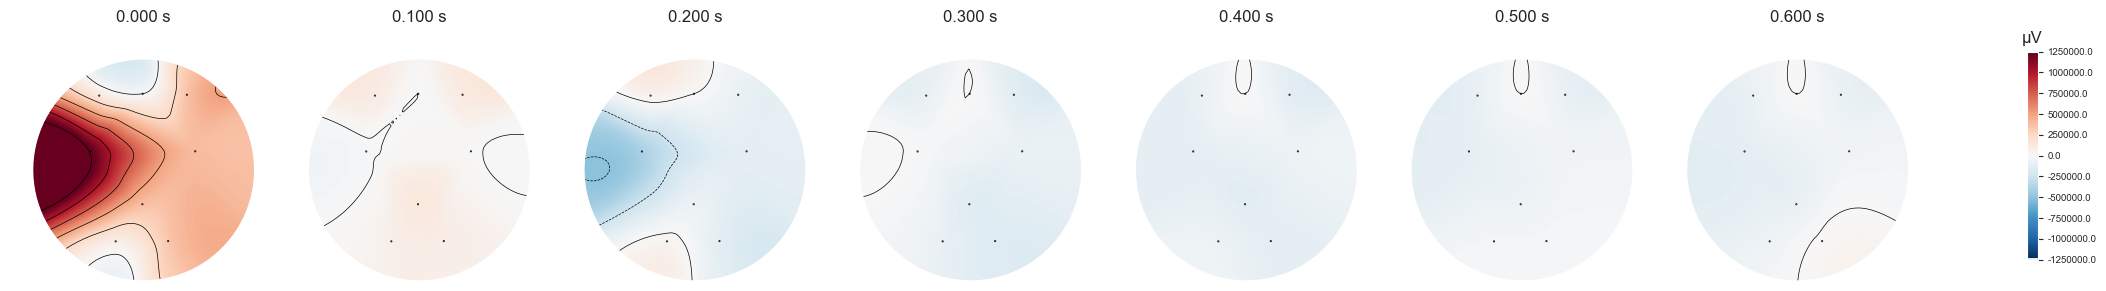

<Figure size 640x480 with 0 Axes>

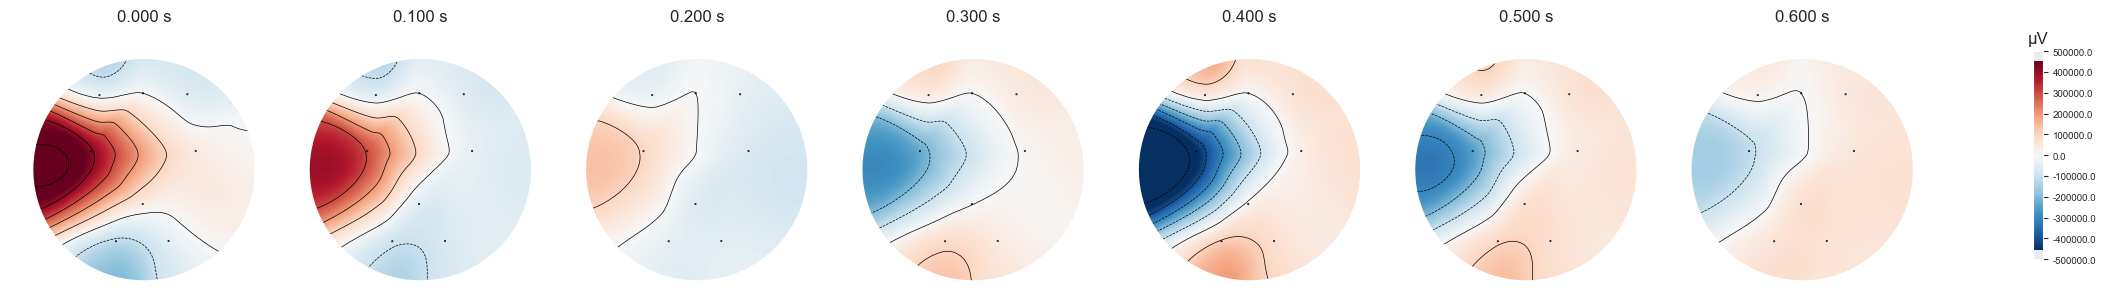

<Figure size 640x480 with 0 Axes>

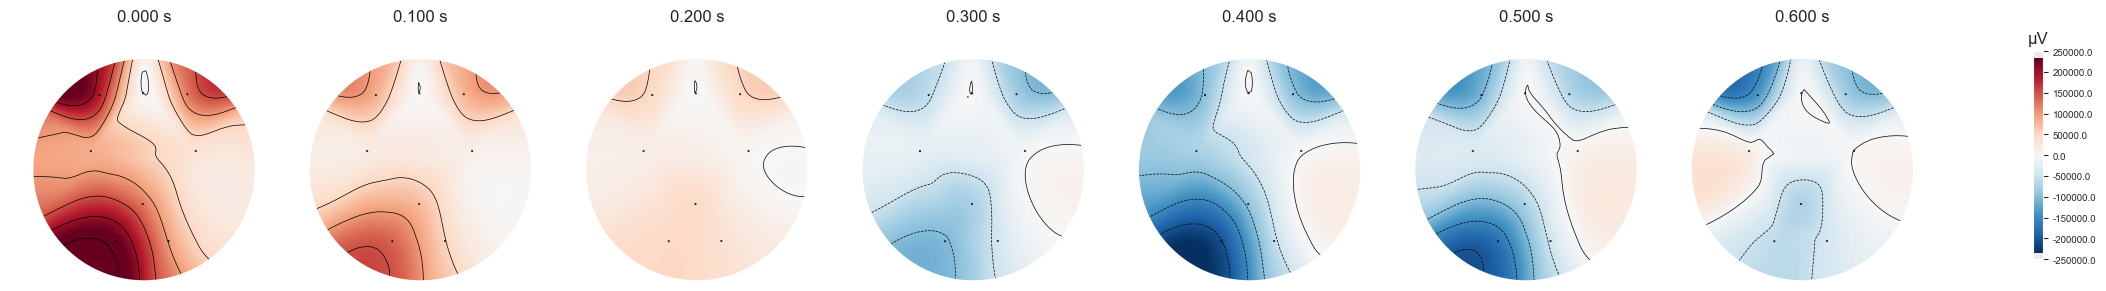

<Figure size 640x480 with 0 Axes>

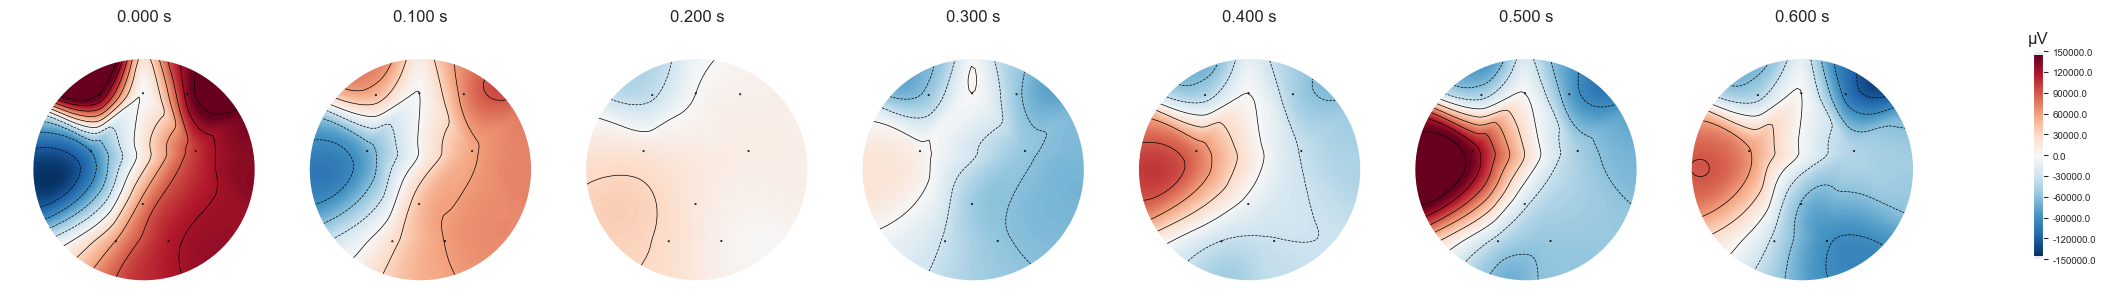

<Figure size 640x480 with 0 Axes>

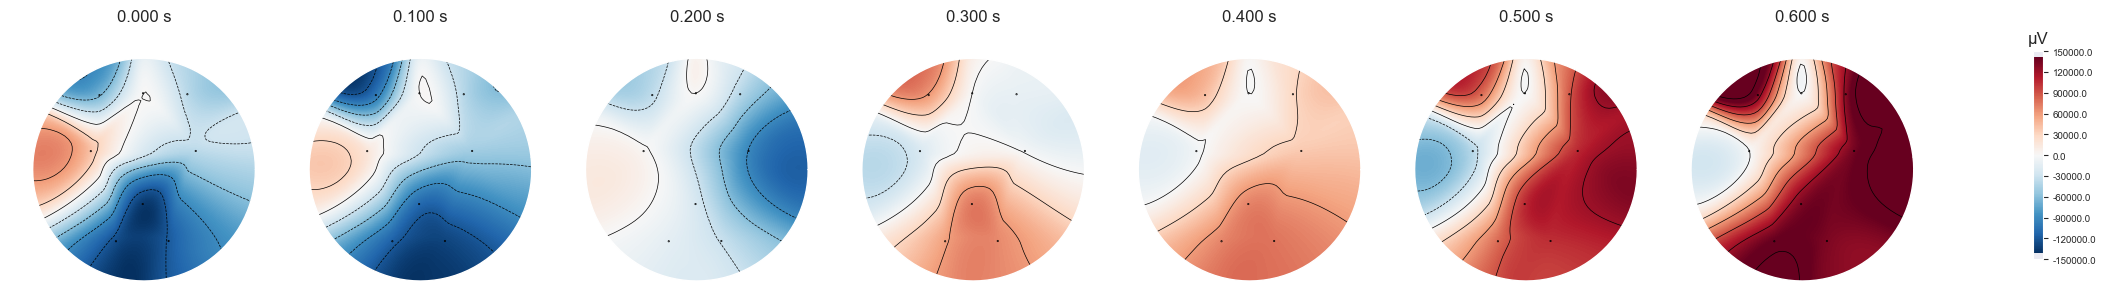

<Figure size 640x480 with 0 Axes>

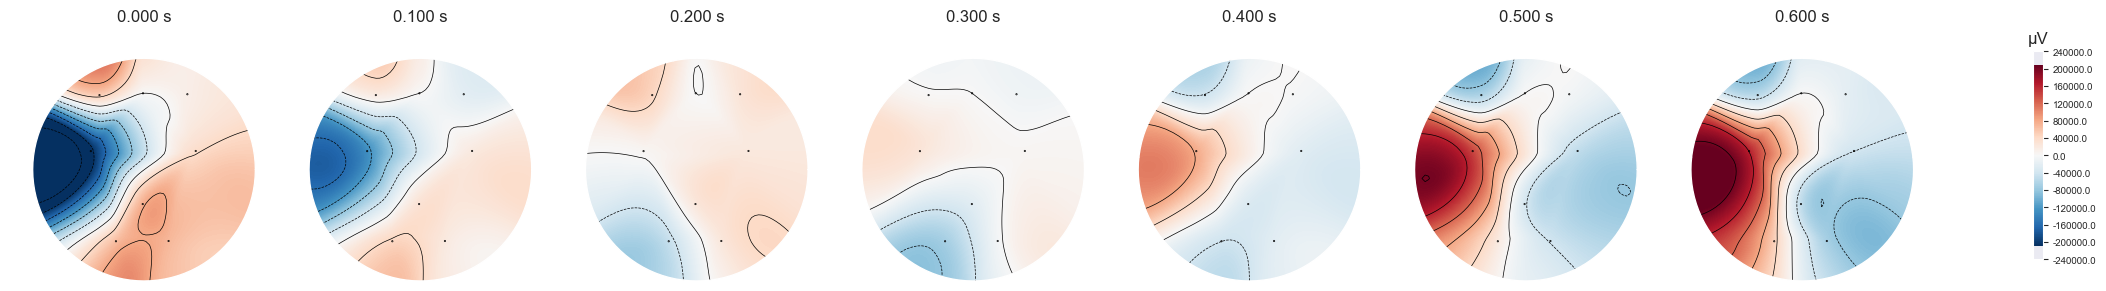

<Figure size 640x480 with 0 Axes>

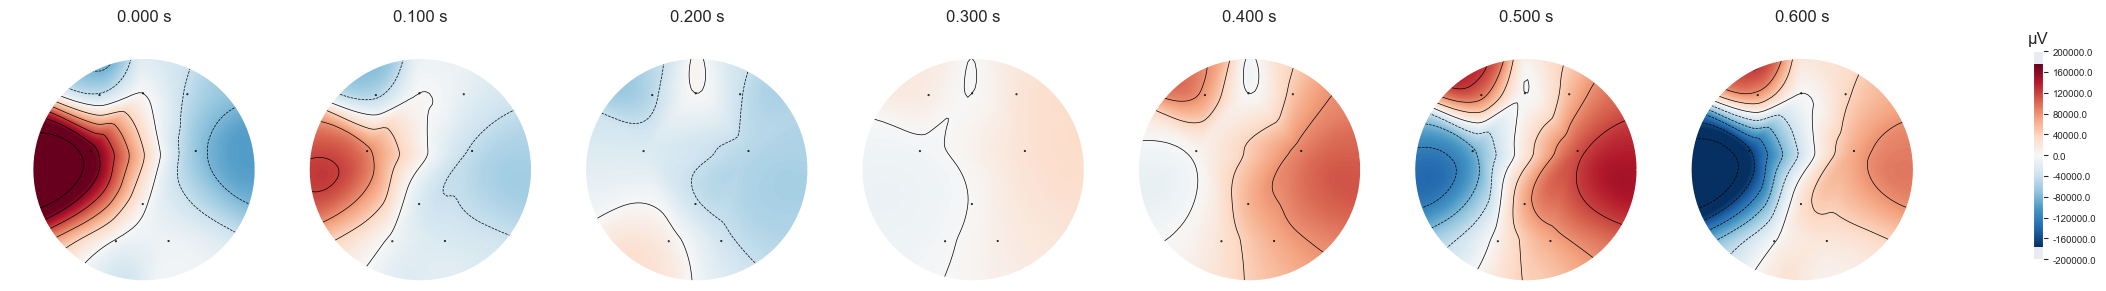

<Figure size 640x480 with 0 Axes>

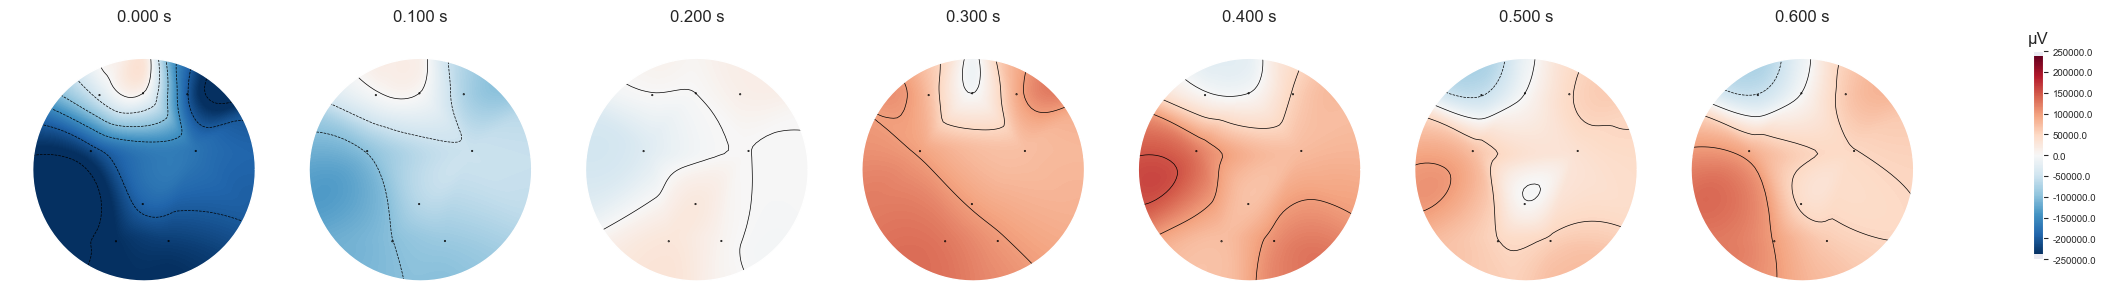

<Figure size 640x480 with 0 Axes>

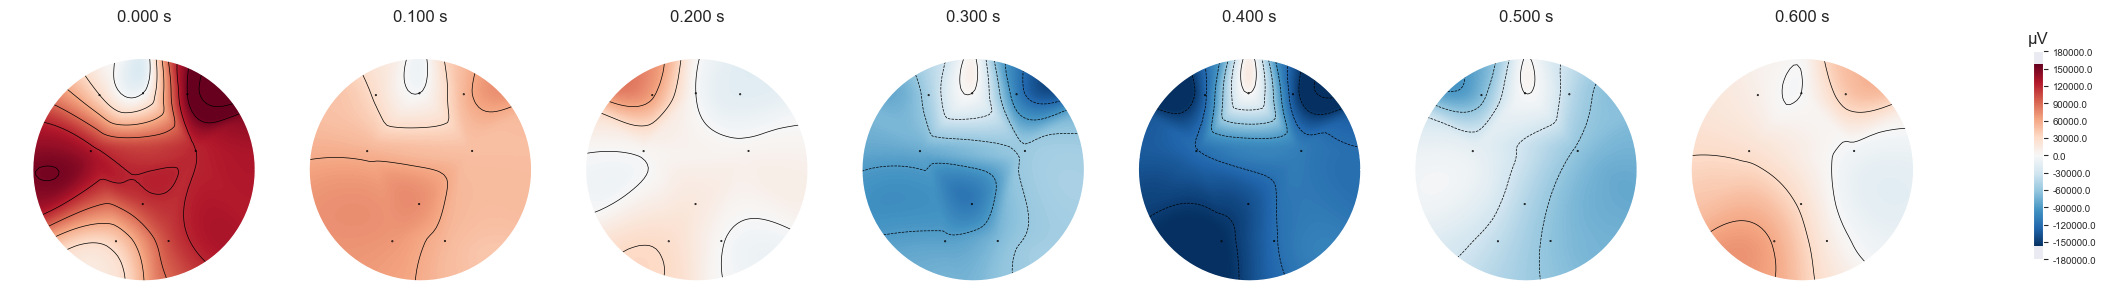

<Figure size 640x480 with 0 Axes>

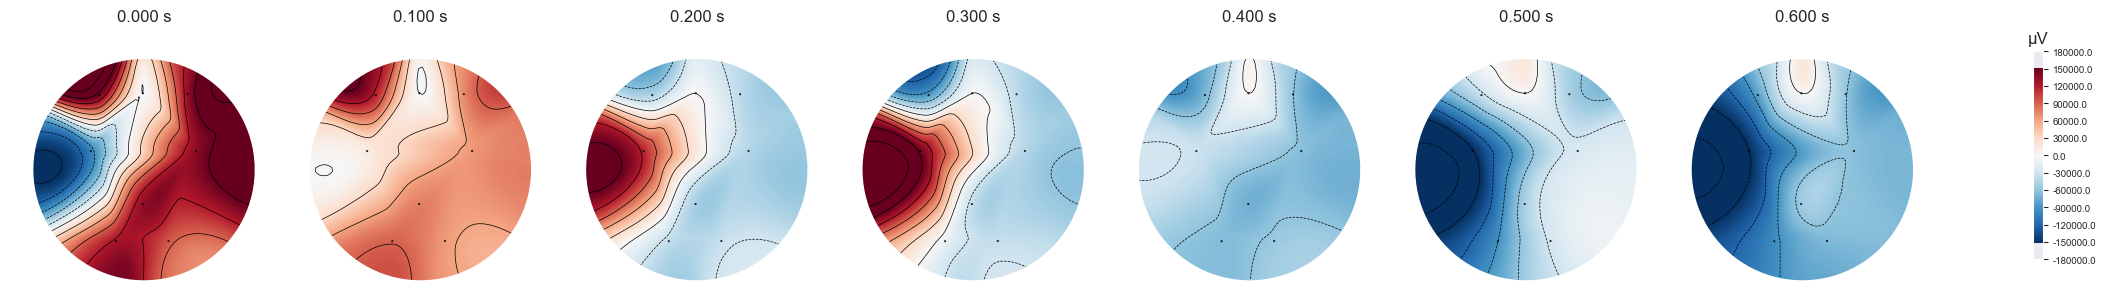

<Figure size 640x480 with 0 Axes>

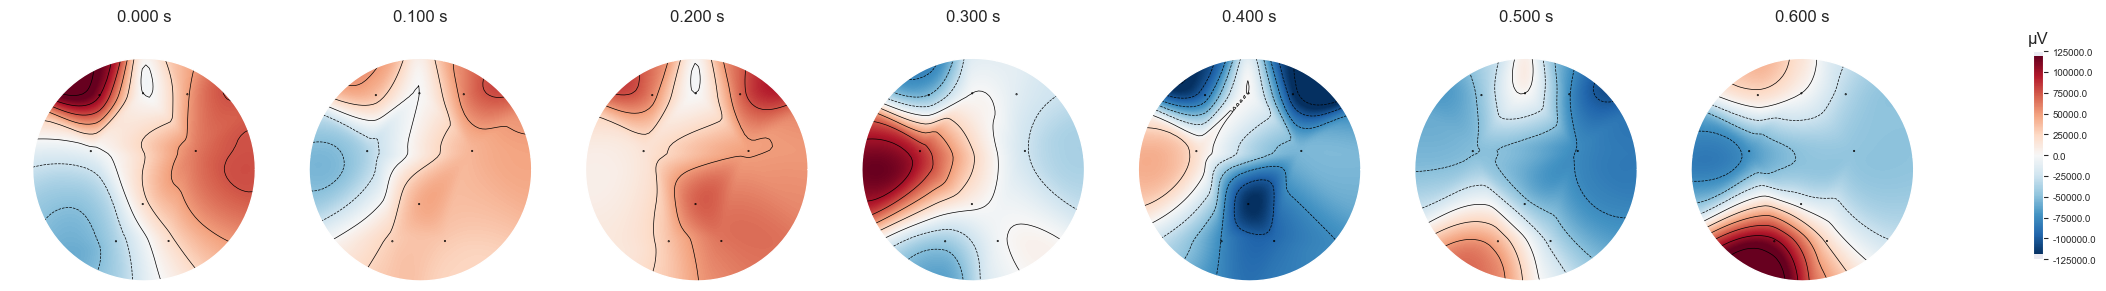

<Figure size 640x480 with 0 Axes>

In [24]:
import numpy as np
import mne
import matplotlib.pyplot as plt

# Set standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
epochsb1.set_montage(montage)

# Print digitization info
print(epochsb1.info['dig'])

# Get recorded times from event sample indices
sample_indices = epochsb1.events[:, 0]
recorded_times = sample_indices / epochsb1.info['sfreq']

# Define scalp plot time points (in seconds)
times = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

# Plot only the first 100 epochs
for i in range(min(20, len(epochsb1))):
    evokedb1 = epochsb1[i:i+1].average()
    time_sec = recorded_times[i]

    fig = mne.viz.plot_evoked_topomap(
        evokedb1,
        times=times,
        size=2,
        show=True,
        outlines='head',
        sensors=True,
        contours=10,
        time_unit='s',
    )
    plt.suptitle(f"Epoch {i+1} — Recorded at {time_sec:.2f} sec", fontsize=14)
    plt.show()

Runnable EEG Topographic CNN Pipeline

In [ ]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

# ==== CONFIGURATION ====
band_name = "beta"           # e.g. 'alpha', 'theta', etc.
serie_name = "clean_eeg1"    # e.g. 'clean_eeg2', 'clean_eeg21', etc.
output_dir = f"images/{band_name}_{serie_name}"

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Set standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
epochsb1.set_montage(montage)

# Print digitization info (optional)
print("Digitization info:")
print(epochsb1.info['dig'])

# Get recorded times from event sample indices
sample_indices = epochsb1.events[:, 0]
recorded_times = sample_indices / epochsb1.info['sfreq']

# Define scalp plot time points (in seconds)
times = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

# ==== LOOP THROUGH ALL EPOCHS ====
n_epochs = len(epochsb1)
print(f"\nSaving {n_epochs} epochs to '{output_dir}' ...\n")

for i in range(n_epochs):
    evokedb1 = epochsb1[i:i+1].average()
    time_sec = recorded_times[i]

    fig = mne.viz.plot_evoked_topomap(
        evokedb1,
        times=times,
        size=2,
        show=False,        # Disable interactive display
        outlines='head',
        sensors=True,
        contours=10,
        time_unit='s',
    )

    plt.suptitle(f"Epoch {i+1} — Recorded at {time_sec:.2f} sec", fontsize=14)

    # Save the figure
    save_path = os.path.join(output_dir, f"epoch_{i+1:03d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 25 == 0 or (i + 1) == n_epochs:
        print(f"✅ Saved {i + 1}/{n_epochs}")

print("\n🎉 All epoch scalp maps saved successfully!")


Digitization info:
[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>, <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>, <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>, <DigPoint |    EEG #22 : (50.3, 87.4, 77.3) mm     : head frame>, <DigPoint |    EEG #40 : (-67.1, 23.4, 104.5) mm   : head frame>, <DigPoint |    EEG #44 : (65.3, 23.6, 103.7) mm    : head frame>, <DigPoint |    EEG #64 : (-1.7, -45.2, 126.7) mm   : head frame>, <DigPoint |    EEG #81 : (-31.6, -80.6, 54.8) mm   : head frame>, <DigPoint |    EEG #83 : (27.7, -80.5, 54.7) mm    : head frame>]

Saving 442 epochs to 'images/beta_clean_eeg1' ...

✅ Saved 25/442


In [25]:
import mne
# Prepare for MNE: Extract EEG data & metadata
channel_names = clean_serie2.columns[1:].tolist()     # All columns except 'Time'
channel_types = ['eeg'] * len(channel_names)

# Transpose EEG data: shape must be [n_channels, n_samples]
eeg_valuesb2 = clean_serie2.iloc[:, 1:].T.values

# Create MNE Info and RawArray
infob2 = mne.create_info(ch_names=channel_names, sfreq=sfreq, ch_types=channel_types)
rawb2 = mne.io.RawArray(eeg_valuesb2, infob2)

# Extract the EEG data for the Delta frequency band (you can change this to any band)
columnsb2 = ["Beta_F3", "Beta_Fz", "Beta_F4", "Beta_C3", "Beta_C4",
           "Beta_Pz", "Beta_O1", "Beta_O2"]
eeg_datab2 = clean_serie2[columnsb2].values.T  # Transpose to (n_channels, n_timepoints)

# Create the info structure for MNE (specifying the channels and their type)
infob2 = mne.create_info(ch_names=[col.split("_")[1] for col in columnsb2], ch_types='eeg', sfreq=sfreq)

# Create the MNE Raw object
rawb2 = mne.io.RawArray(eeg_datab2, infob2)

# Let's create an Epochs object to allow for topomap plotting
# We'll use a 1 second interval for each epoch, assuming that the data is 1-second samples
eventsb2 = mne.make_fixed_length_events(rawb2, duration=1)  # Create events every 1 second
epochsb2 = mne.Epochs(rawb1, eventsb2, tmin=0, tmax=1, baseline=None, detrend=1)

# Check the unique event IDs in the raw events
print(epochsb2.event_id)

# Define the events: for example, let's assume you want to create events manually
eventsb2 = mne.make_fixed_length_events(rawb2, duration=1)  # Example, you may adjust based on your data

# Define the event dictionary: mapping event names to event IDs
event_dictb2 = {'button': 1, 'face': 2}

# You can check the events like this
print(eventsb2)

print(epochsb2)

print(epochsb2.info)

epochsb2.load_data()  #This will load the data for all epochs

print(f"Total epochs: {len(epochsb2)}")
print(f"Time points: {len(epochsb2.times)}")
print(f"Channel names: {epochsb2.ch_names}")
print(f"Data shape for epoch[1]: {epochsb2[1].get_data().shape}")  # Should be (1, n_channels, n_times)

Creating RawArray with float64 data, n_channels=40, n_times=24249
    Range : 0 ... 24248 =      0.000 ...   404.066 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=24249
    Range : 0 ... 24248 =      0.000 ...   404.066 secs
Ready.
Not setting metadata
404 matching events found
No baseline correction applied
0 projection items activated
{'1': 1}
[[    0     0     1]
 [   60     0     1]
 [  120     0     1]
 ...
 [24064     0     1]
 [24124     0     1]
 [24184     0     1]]
<Epochs | 404 events (good & bad), 0 – 1 s (baseline off), ~11 KiB, data not loaded,
 '1': 404>
<Info | 7 non-empty values
 bads: []
 ch_names: F3, Fz, F4, C3, C4, Pz, O1, O2
 chs: 8 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 30.0 Hz
 meas_date: unspecified
 nchan: 8
 projs: []
 sfreq: 60.0 Hz
>
Using data from preloaded Raw for 404 events and 61 original time points ...
0 bad epochs dropped
Total epochs: 404
Time points: 61
Channel names: ['F3', 'Fz', 'F4', 'C3', 'C4', 'Pz'

In [50]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

# ==== CONFIGURATION ====
band_name = "beta"           # e.g. 'alpha', 'theta', etc.
serie_name = "clean_eeg2"    # e.g. 'clean_eeg2', 'clean_eeg21', etc.
output_dir = f"images/{band_name}_{serie_name}"

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Set standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
epochsb2.set_montage(montage)

# Print digitization info (optional)
print("Digitization info:")
print(epochsb2.info['dig'])

# Get recorded times from event sample indices
sample_indices = epochsb2.events[:, 0]
recorded_times = sample_indices / epochsb2.info['sfreq']

# Define scalp plot time points (in seconds)
times = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

# ==== LOOP THROUGH ALL EPOCHS ====
n_epochs = len(epochsb2)
print(f"\nSaving {n_epochs} epochs to '{output_dir}' ...\n")

for i in range(n_epochs):
    evokedb2 = epochsb2[i:i+1].average()
    time_sec = recorded_times[i]

    fig = mne.viz.plot_evoked_topomap(
        evokedb2,
        times=times,
        size=2,
        show=False,        # Disable interactive display
        outlines='head',
        sensors=True,
        contours=10,
        time_unit='s',
    )

    plt.suptitle(f"Epoch {i+1} — Recorded at {time_sec:.2f} sec", fontsize=14)

    # Save the figure
    save_path = os.path.join(output_dir, f"epoch_{i+1:03d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 25 == 0 or (i + 1) == n_epochs:
        print(f"✅ Saved {i + 1}/{n_epochs}")

print("\n🎉 All epoch scalp maps saved successfully!")


Digitization info:
[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>, <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>, <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>, <DigPoint |    EEG #22 : (50.3, 87.4, 77.3) mm     : head frame>, <DigPoint |    EEG #40 : (-67.1, 23.4, 104.5) mm   : head frame>, <DigPoint |    EEG #44 : (65.3, 23.6, 103.7) mm    : head frame>, <DigPoint |    EEG #64 : (-1.7, -45.2, 126.7) mm   : head frame>, <DigPoint |    EEG #81 : (-31.6, -80.6, 54.8) mm   : head frame>, <DigPoint |    EEG #83 : (27.7, -80.5, 54.7) mm    : head frame>]

Saving 404 epochs to 'images/beta_clean_eeg2' ...

✅ Saved 25/404
✅ Saved 50/404
✅ Saved 75/404
✅ Saved 100/404
✅ Saved 125/404
✅ Saved 150/404
✅ Saved 175/404
✅ Saved 200/404
✅ Saved 225/404
✅ Saved 250/404
✅ Saved 275/404
✅ Saved 300/404
✅ Saved 325/4

In [27]:
import mne
# Prepare for MNE: Extract EEG data & metadata
channel_names = clean_serie3.columns[1:].tolist()     # All columns except 'Time'
channel_types = ['eeg'] * len(channel_names)

# Transpose EEG data: shape must be [n_channels, n_samples]
eeg_values3 = clean_serie3.iloc[:, 1:].T.values

# Create MNE Info and RawArray
infob3 = mne.create_info(ch_names=channel_names, sfreq=sfreq, ch_types=channel_types)
rawb3 = mne.io.RawArray(eeg_values3, infob3)

# Extract the EEG data for the Delta frequency band (you can change this to any band)
columnsb3 = ["Beta_F3", "Beta_Fz", "Beta_F4", "Beta_C3", "Beta_C4",
           "Beta_Pz", "Beta_O1", "Beta_O2"]
eeg_datab3 = clean_serie3[columnsb3].values.T  # Transpose to (n_channels, n_timepoints)

# Create the info structure for MNE (specifying the channels and their type)
infob3 = mne.create_info(ch_names=[col.split("_")[1] for col in columnsb3], ch_types='eeg', sfreq=sfreq)

# Create the MNE Raw object
rawb3 = mne.io.RawArray(eeg_datab3, infob3)

# Let's create an Epochs object to allow for topomap plotting
# We'll use a 1 second interval for each epoch, assuming that the data is 1-second samples
eventsb3 = mne.make_fixed_length_events(rawb3, duration=1)  # Create events every 1 second
epochsb3 = mne.Epochs(rawb3, eventsb3, tmin=0, tmax=1, baseline=None, detrend=1)

# Check the unique event IDs in the raw events
print(epochsb3.event_id)

# Define the events: for example, let's assume you want to create events manually
eventsb3 = mne.make_fixed_length_events(rawb3, duration=1)  # Example, you may adjust based on your data

# Define the event dictionary: mapping event names to event IDs
event_dictb3 = {'button': 1, 'face': 2}

# You can check the events like this
print(eventsb3)

print(epochsb3)

print(epochsb3.info)

epochsb3.load_data()  #This will load the data for all epochs

print(f"Total epochs: {len(epochsb3)}")
print(f"Time points: {len(epochsb3.times)}")
print(f"Channel names: {epochsb3.ch_names}")
print(f"Data shape for epoch[1]: {epochsb3[1].get_data().shape}")  # Should be (1, n_channels, n_times)

Creating RawArray with float64 data, n_channels=40, n_times=17688
    Range : 0 ... 17687 =      0.000 ...   294.734 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=17688
    Range : 0 ... 17687 =      0.000 ...   294.734 secs
Ready.
Not setting metadata
294 matching events found
No baseline correction applied
0 projection items activated
{'1': 1}
[[    0     0     1]
 [   60     0     1]
 [  120     0     1]
 [  180     0     1]
 [  240     0     1]
 [  300     0     1]
 [  360     0     1]
 [  420     0     1]
 [  480     0     1]
 [  540     0     1]
 [  600     0     1]
 [  660     0     1]
 [  720     0     1]
 [  780     0     1]
 [  840     0     1]
 [  900     0     1]
 [  960     0     1]
 [ 1020     0     1]
 [ 1080     0     1]
 [ 1140     0     1]
 [ 1200     0     1]
 [ 1260     0     1]
 [ 1320     0     1]
 [ 1380     0     1]
 [ 1440     0     1]
 [ 1500     0     1]
 [ 1560     0     1]
 [ 1620     0     1]
 [ 1680     0     1]
 [ 1740     0     

In [38]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

# ==== CONFIGURATION ====
band_name = "beta"           # e.g. 'alpha', 'theta', etc.
serie_name = "clean_eeg3"    # e.g. 'clean_eeg2', 'clean_eeg21', etc.
output_dir = f"images/{band_name}_{serie_name}"

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Set standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
epochsb3.set_montage(montage)

# Print digitization info (optional)
print("Digitization info:")
print(epochsb3.info['dig'])

# Get recorded times from event sample indices
sample_indices = epochsb3.events[:, 0]
recorded_times = sample_indices / epochsb3.info['sfreq']

# Define scalp plot time points (in seconds)
times = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

# ==== LOOP THROUGH ALL EPOCHS ====
n_epochs = len(epochsb3)
print(f"\nSaving {n_epochs} epochs to '{output_dir}' ...\n")

for i in range(n_epochs):
    evokedb3 = epochsb3[i:i+1].average()
    time_sec = recorded_times[i]

    fig = mne.viz.plot_evoked_topomap(
        evokedb3,
        times=times,
        size=2,
        show=False,        # Disable interactive display
        outlines='head',
        sensors=True,
        contours=10,
        time_unit='s',
    )

    plt.suptitle(f"Epoch {i+1} — Recorded at {time_sec:.2f} sec", fontsize=14)

    # Save the figure
    save_path = os.path.join(output_dir, f"epoch_{i+1:03d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 25 == 0 or (i + 1) == n_epochs:
        print(f"✅ Saved {i + 1}/{n_epochs}")

print("\n🎉 All epoch scalp maps saved successfully!")


Digitization info:
[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>, <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>, <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>, <DigPoint |    EEG #22 : (50.3, 87.4, 77.3) mm     : head frame>, <DigPoint |    EEG #40 : (-67.1, 23.4, 104.5) mm   : head frame>, <DigPoint |    EEG #44 : (65.3, 23.6, 103.7) mm    : head frame>, <DigPoint |    EEG #64 : (-1.7, -45.2, 126.7) mm   : head frame>, <DigPoint |    EEG #81 : (-31.6, -80.6, 54.8) mm   : head frame>, <DigPoint |    EEG #83 : (27.7, -80.5, 54.7) mm    : head frame>]

Saving 442 epochs to 'images/beta_clean_eeg3' ...

✅ Saved 25/442
✅ Saved 50/442
✅ Saved 75/442
✅ Saved 100/442
✅ Saved 125/442
✅ Saved 150/442
✅ Saved 175/442
✅ Saved 200/442
✅ Saved 225/442
✅ Saved 250/442
✅ Saved 275/442
✅ Saved 300/442
✅ Saved 325/4

In [29]:
import mne
# Prepare for MNE: Extract EEG data & metadata
channel_names = clean_serie11.columns[1:].tolist()     # All columns except 'Time'
channel_types = ['eeg'] * len(channel_names)

# Transpose EEG data: shape must be [n_channels, n_samples]
eeg_valuesb11 = clean_serie11.iloc[:, 1:].T.values

# Create MNE Info and RawArray
infob11 = mne.create_info(ch_names=channel_names, sfreq=sfreq, ch_types=channel_types)
rawb11 = mne.io.RawArray(eeg_valuesb11, infob11)

# Extract the EEG data for the Delta frequency band (you can change this to any band)
columnsb11 = ["Beta_F3", "Beta_Fz", "Beta_F4", "Beta_C3", "Beta_C4",
           "Beta_Pz", "Beta_O1", "Beta_O2"]
eeg_datab11 = clean_serie11[columnsb11].values.T  # Transpose to (n_channels, n_timepoints)

# Create the info structure for MNE (specifying the channels and their type)
infob11 = mne.create_info(ch_names=[col.split("_")[1] for col in columnsb11], ch_types='eeg', sfreq=sfreq)

# Create the MNE Raw object
rawb11 = mne.io.RawArray(eeg_datab11, infob11)

# Let's create an Epochs object to allow for topomap plotting
# We'll use a 1 second interval for each epoch, assuming that the data is 1-second samples
eventsb11 = mne.make_fixed_length_events(rawb11, duration=1)  # Create events every 1 second
epochsb11 = mne.Epochs(rawb11, eventsb11, tmin=0, tmax=1, baseline=None, detrend=1)

# Check the unique event IDs in the raw events
print(epochsb11.event_id)

# Define the events: for example, let's assume you want to create events manually
eventsb11 = mne.make_fixed_length_events(rawb11, duration=1)  # Example, you may adjust based on your data

# Define the event dictionary: mapping event names to event IDs
event_dictb11 = {'button': 1, 'face': 2}

# You can check the events like this
print(eventsb11)

print(epochsb11)

print(epochsb11.info)

epochsb11.load_data()  #This will load the data for all epochs

print(f"Total epochs: {len(epochsb11)}")
print(f"Time points: {len(epochsb11.times)}")
print(f"Channel names: {epochsb11.ch_names}")
print(f"Data shape for epoch[1]: {epochsb11[1].get_data().shape}")  # Should be (1, n_channels, n_times)

Creating RawArray with float64 data, n_channels=40, n_times=23393
    Range : 0 ... 23392 =      0.000 ...   389.802 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=23393
    Range : 0 ... 23392 =      0.000 ...   389.802 secs
Ready.
Not setting metadata
389 matching events found
No baseline correction applied
0 projection items activated
{'1': 1}
[[    0     0     1]
 [   60     0     1]
 [  120     0     1]
 ...
 [23163     0     1]
 [23223     0     1]
 [23283     0     1]]
<Epochs | 389 events (good & bad), 0 – 1 s (baseline off), ~11 KiB, data not loaded,
 '1': 389>
<Info | 7 non-empty values
 bads: []
 ch_names: F3, Fz, F4, C3, C4, Pz, O1, O2
 chs: 8 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 30.0 Hz
 meas_date: unspecified
 nchan: 8
 projs: []
 sfreq: 60.0 Hz
>
Using data from preloaded Raw for 389 events and 61 original time points ...
0 bad epochs dropped
Total epochs: 389
Time points: 61
Channel names: ['F3', 'Fz', 'F4', 'C3', 'C4', 'Pz'

In [44]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

# ==== CONFIGURATION ====
band_name = "beta"           # e.g. 'alpha', 'theta', etc.
serie_name = "clean_eeg11"    # e.g. 'clean_eeg2', 'clean_eeg21', etc.
output_dir = f"images/{band_name}_{serie_name}"

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Set standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
epochsb11.set_montage(montage)

# Print digitization info (optional)
print("Digitization info:")
print(epochsb11.info['dig'])

# Get recorded times from event sample indices
sample_indices = epochsb11.events[:, 0]
recorded_times = sample_indices / epochsb11.info['sfreq']

# Define scalp plot time points (in seconds)
times = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

# ==== LOOP THROUGH ALL EPOCHS ====
n_epochs = len(epochsb11)
print(f"\nSaving {n_epochs} epochs to '{output_dir}' ...\n")

for i in range(n_epochs):
    evokedb11 = epochsb11[i:i+1].average()
    time_sec = recorded_times[i]

    fig = mne.viz.plot_evoked_topomap(
        evokedb11,
        times=times,
        size=2,
        show=False,        # Disable interactive display
        outlines='head',
        sensors=True,
        contours=10,
        time_unit='s',
    )

    plt.suptitle(f"Epoch {i+1} — Recorded at {time_sec:.2f} sec", fontsize=14)

    # Save the figure
    save_path = os.path.join(output_dir, f"epoch_{i+1:03d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 25 == 0 or (i + 1) == n_epochs:
        print(f"✅ Saved {i + 1}/{n_epochs}")

print("\n🎉 All epoch scalp maps saved successfully!")


Digitization info:
[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>, <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>, <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>, <DigPoint |    EEG #22 : (50.3, 87.4, 77.3) mm     : head frame>, <DigPoint |    EEG #40 : (-67.1, 23.4, 104.5) mm   : head frame>, <DigPoint |    EEG #44 : (65.3, 23.6, 103.7) mm    : head frame>, <DigPoint |    EEG #64 : (-1.7, -45.2, 126.7) mm   : head frame>, <DigPoint |    EEG #81 : (-31.6, -80.6, 54.8) mm   : head frame>, <DigPoint |    EEG #83 : (27.7, -80.5, 54.7) mm    : head frame>]

Saving 442 epochs to 'images/beta_clean_eeg11' ...

✅ Saved 25/442
✅ Saved 50/442
✅ Saved 75/442
✅ Saved 100/442
✅ Saved 125/442
✅ Saved 150/442
✅ Saved 175/442
✅ Saved 200/442
✅ Saved 225/442
✅ Saved 250/442
✅ Saved 275/442
✅ Saved 300/442
✅ Saved 325/

In [30]:
import mne
# Prepare for MNE: Extract EEG data & metadata
channel_names = clean_serie21.columns[1:].tolist()     # All columns except 'Time'
channel_types = ['eeg'] * len(channel_names)

# Transpose EEG data: shape must be [n_channels, n_samples]
eeg_valuesb21 = clean_serie21.iloc[:, 1:].T.values

# Create MNE Info and RawArray
infob21 = mne.create_info(ch_names=channel_names, sfreq=sfreq, ch_types=channel_types)
rawb21 = mne.io.RawArray(eeg_valuesb21, infob21)

# Extract the EEG data for the Delta frequency band (you can change this to any band)
columnsb21 = ["Beta_F3", "Beta_Fz", "Beta_F4", "Beta_C3", "Beta_C4",
           "Beta_Pz", "Beta_O1", "Beta_O2"]
eeg_datab21 = clean_serie21[columnsb21].values.T  # Transpose to (n_channels, n_timepoints)

# Create the info structure for MNE (specifying the channels and their type)
infob21 = mne.create_info(ch_names=[col.split("_")[1] for col in columnsb21], ch_types='eeg', sfreq=sfreq)

# Create the MNE Raw object
rawb21 = mne.io.RawArray(eeg_datab21, infob21)

# Let's create an Epochs object to allow for topomap plotting
# We'll use a 1 second interval for each epoch, assuming that the data is 1-second samples
eventsb21 = mne.make_fixed_length_events(rawb21, duration=1)  # Create events every 1 second
epochsb21 = mne.Epochs(rawb21, eventsb21, tmin=0, tmax=1, baseline=None, detrend=1)

# Check the unique event IDs in the raw events
print(epochsb21.event_id)

# Define the events: for example, let's assume you want to create events manually
eventsb21 = mne.make_fixed_length_events(rawb21, duration=1)  # Example, you may adjust based on your data

# Define the event dictionary: mapping event names to event IDs
event_dictb21 = {'button': 1, 'face': 2}

# You can check the events like this
print(eventsb21)

print(epochsb21)

print(epochsb21.info)

epochsb21.load_data()  #This will load the data for all epochs

print(f"Total epochs: {len(epochsb21)}")
print(f"Time points: {len(epochsb21.times)}")
print(f"Channel names: {epochsb21.ch_names}")
print(f"Data shape for epoch[1]: {epochsb21[1].get_data().shape}")  # Should be (1, n_channels, n_times)

Creating RawArray with float64 data, n_channels=40, n_times=25105
    Range : 0 ... 25104 =      0.000 ...   418.330 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=25105
    Range : 0 ... 25104 =      0.000 ...   418.330 secs
Ready.
Not setting metadata
418 matching events found
No baseline correction applied
0 projection items activated
{'1': 1}
[[    0     0     1]
 [   60     0     1]
 [  120     0     1]
 ...
 [24904     0     1]
 [24964     0     1]
 [25024     0     1]]
<Epochs | 418 events (good & bad), 0 – 1 s (baseline off), ~11 KiB, data not loaded,
 '1': 418>
<Info | 7 non-empty values
 bads: []
 ch_names: F3, Fz, F4, C3, C4, Pz, O1, O2
 chs: 8 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 30.0 Hz
 meas_date: unspecified
 nchan: 8
 projs: []
 sfreq: 60.0 Hz
>
Using data from preloaded Raw for 418 events and 61 original time points ...
0 bad epochs dropped
Total epochs: 418
Time points: 61
Channel names: ['F3', 'Fz', 'F4', 'C3', 'C4', 'Pz'

In [31]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

# ==== CONFIGURATION ====
band_name = "beta"           # e.g. 'alpha', 'theta', etc.
serie_name = "clean_eeg21"    # e.g. 'clean_eeg2', 'clean_eeg21', etc.
output_dir = f"images/{band_name}_{serie_name}"

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Set standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
epochsb21.set_montage(montage)

# Print digitization info (optional)
print("Digitization info:")
print(epochsb21.info['dig'])

# Get recorded times from event sample indices
sample_indices = epochsb21.events[:, 0]
recorded_times = sample_indices / epochsb21.info['sfreq']

# Define scalp plot time points (in seconds)
times = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

# ==== LOOP THROUGH ALL EPOCHS ====
n_epochs = len(epochsb21)
print(f"\nSaving {n_epochs} epochs to '{output_dir}' ...\n")

for i in range(n_epochs):
    evokedb21 = epochsb21[i:i+1].average()
    time_sec = recorded_times[i]

    fig = mne.viz.plot_evoked_topomap(
        evokedb21,
        times=times,
        size=2,
        show=False,        # Disable interactive display
        outlines='head',
        sensors=True,
        contours=10,
        time_unit='s',
    )

    plt.suptitle(f"Epoch {i+1} — Recorded at {time_sec:.2f} sec", fontsize=14)

    # Save the figure
    save_path = os.path.join(output_dir, f"epoch_{i+1:03d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 25 == 0 or (i + 1) == n_epochs:
        print(f"✅ Saved {i + 1}/{n_epochs}")

print("\n🎉 All epoch scalp maps saved successfully!")


Digitization info:
[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>, <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>, <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>, <DigPoint |    EEG #22 : (50.3, 87.4, 77.3) mm     : head frame>, <DigPoint |    EEG #40 : (-67.1, 23.4, 104.5) mm   : head frame>, <DigPoint |    EEG #44 : (65.3, 23.6, 103.7) mm    : head frame>, <DigPoint |    EEG #64 : (-1.7, -45.2, 126.7) mm   : head frame>, <DigPoint |    EEG #81 : (-31.6, -80.6, 54.8) mm   : head frame>, <DigPoint |    EEG #83 : (27.7, -80.5, 54.7) mm    : head frame>]

Saving 418 epochs to 'images/beta_clean_eeg21' ...

✅ Saved 25/418
✅ Saved 50/418
✅ Saved 75/418
✅ Saved 100/418
✅ Saved 125/418
✅ Saved 150/418
✅ Saved 175/418
✅ Saved 200/418
✅ Saved 225/418
✅ Saved 250/418
✅ Saved 275/418
✅ Saved 300/418
✅ Saved 325/

In [32]:
import mne
# Prepare for MNE: Extract EEG data & metadata
channel_names = clean_serie31.columns[1:].tolist()     # All columns except 'Time'
channel_types = ['eeg'] * len(channel_names)

# Transpose EEG data: shape must be [n_channels, n_samples]
eeg_valuesb31 = clean_serie31.iloc[:, 1:].T.values

# Create MNE Info and RawArray
infob31 = mne.create_info(ch_names=channel_names, sfreq=sfreq, ch_types=channel_types)
rawb31 = mne.io.RawArray(eeg_valuesb31, infob31)

# Extract the EEG data for the Delta frequency band (you can change this to any band)
columnsb31 = ["Beta_F3", "Beta_Fz", "Beta_F4", "Beta_C3", "Beta_C4",
           "Beta_Pz", "Beta_O1", "Beta_O2"]
eeg_datab31 = clean_serie31[columnsb31].values.T  # Transpose to (n_channels, n_timepoints)

# Create the info structure for MNE (specifying the channels and their type)
infob31 = mne.create_info(ch_names=[col.split("_")[1] for col in columnsb31], ch_types='eeg', sfreq=sfreq)

# Create the MNE Raw object
rawb31 = mne.io.RawArray(eeg_datab31, infob31)

# Let's create an Epochs object to allow for topomap plotting
# We'll use a 1 second interval for each epoch, assuming that the data is 1-second samples
eventsb31 = mne.make_fixed_length_events(rawb31, duration=1)  # Create events every 1 second
epochsb31 = mne.Epochs(rawb31, eventsb31, tmin=0, tmax=1, baseline=None, detrend=1)

# Check the unique event IDs in the raw events
print(epochsb31.event_id)

# Define the events: for example, let's assume you want to create events manually
eventsb31 = mne.make_fixed_length_events(rawb31, duration=1)  # Example, you may adjust based on your data

# Define the event dictionary: mapping event names to event IDs
event_dictb31 = {'button': 1, 'face': 2}

# You can check the events like this
print(eventsb31)

print(epochsb31)

print(epochsb31.info)

epochsb31.load_data()  #This will load the data for all epochs

print(f"Total epochs: {len(epochsb31)}")
print(f"Time points: {len(epochsb31.times)}")
print(f"Channel names: {epochsb31.ch_names}")
print(f"Data shape for epoch[1]: {epochsb31[1].get_data().shape}")  # Should be (1, n_channels, n_times)

Creating RawArray with float64 data, n_channels=40, n_times=18638
    Range : 0 ... 18637 =      0.000 ...   310.565 secs
Ready.
Creating RawArray with float64 data, n_channels=8, n_times=18638
    Range : 0 ... 18637 =      0.000 ...   310.565 secs
Ready.
Not setting metadata
310 matching events found
No baseline correction applied
0 projection items activated
{'1': 1}
[[    0     0     1]
 [   60     0     1]
 [  120     0     1]
 [  180     0     1]
 [  240     0     1]
 [  300     0     1]
 [  360     0     1]
 [  420     0     1]
 [  480     0     1]
 [  540     0     1]
 [  600     0     1]
 [  660     0     1]
 [  720     0     1]
 [  780     0     1]
 [  840     0     1]
 [  900     0     1]
 [  960     0     1]
 [ 1020     0     1]
 [ 1080     0     1]
 [ 1140     0     1]
 [ 1200     0     1]
 [ 1260     0     1]
 [ 1320     0     1]
 [ 1380     0     1]
 [ 1440     0     1]
 [ 1500     0     1]
 [ 1560     0     1]
 [ 1620     0     1]
 [ 1680     0     1]
 [ 1740     0     

In [33]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

# ==== CONFIGURATION ====
band_name = "beta"           # e.g. 'alpha', 'theta', etc.
serie_name = "clean_eeg31"    # e.g. 'clean_eeg2', 'clean_eeg31', etc.
output_dir = f"images/{band_name}_{serie_name}"

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Set standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
epochsb31.set_montage(montage)

# Print digitization info (optional)
print("Digitization info:")
print(epochsb31.info['dig'])

# Get recorded times from event sample indices
sample_indices = epochsb31.events[:, 0]
recorded_times = sample_indices / epochsb31.info['sfreq']

# Define scalp plot time points (in seconds)
times = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

# ==== LOOP THROUGH ALL EPOCHS ====
n_epochs = len(epochsb31)
print(f"\nSaving {n_epochs} epochs to '{output_dir}' ...\n")

for i in range(n_epochs):
    evokedb31 = epochsb31[i:i+1].average()
    time_sec = recorded_times[i]

    fig = mne.viz.plot_evoked_topomap(
        evokedb31,
        times=times,
        size=2,
        show=False,        # Disable interactive display
        outlines='head',
        sensors=True,
        contours=10,
        time_unit='s',
    )

    plt.suptitle(f"Epoch {i+1} — Recorded at {time_sec:.2f} sec", fontsize=14)

    # Save the figure
    save_path = os.path.join(output_dir, f"epoch_{i+1:03d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 25 == 0 or (i + 1) == n_epochs:
        print(f"✅ Saved {i + 1}/{n_epochs}")

print("\n🎉 All epoch scalp maps saved successfully!")


Digitization info:
[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>, <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>, <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>, <DigPoint |    EEG #22 : (50.3, 87.4, 77.3) mm     : head frame>, <DigPoint |    EEG #40 : (-67.1, 23.4, 104.5) mm   : head frame>, <DigPoint |    EEG #44 : (65.3, 23.6, 103.7) mm    : head frame>, <DigPoint |    EEG #64 : (-1.7, -45.2, 126.7) mm   : head frame>, <DigPoint |    EEG #81 : (-31.6, -80.6, 54.8) mm   : head frame>, <DigPoint |    EEG #83 : (27.7, -80.5, 54.7) mm    : head frame>]

Saving 310 epochs to 'images/beta_clean_eeg31' ...

✅ Saved 25/310
✅ Saved 50/310
✅ Saved 75/310
✅ Saved 100/310
✅ Saved 125/310
✅ Saved 150/310
✅ Saved 175/310
✅ Saved 200/310
✅ Saved 225/310
✅ Saved 250/310
✅ Saved 275/310
✅ Saved 300/310
✅ Saved 310/

TRY 2

In [23]:
# ================================================
# 1. Imports & GPU check
# ================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torch.optim as optim

import mne
from scipy.interpolate import griddata

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [24]:
# ================================================
# 2. USE YOUR EXISTING DATAFRAMES
# ================================================
train_series = {
    "clean_serie1": clean_serie1,
    "clean_serie2": clean_serie2,
    "clean_serie11": clean_serie11,
    "clean_serie21": clean_serie21,
}

test_series = {
    "clean_serie3": clean_serie3,
    "clean_serie31": clean_serie31,
}

print("Train series loaded:", list(train_series.keys()))
print("Test series loaded:", list(test_series.keys()))


Train series loaded: ['clean_serie1', 'clean_serie2', 'clean_serie11', 'clean_serie21']
Test series loaded: ['clean_serie3', 'clean_serie31']


In [25]:
# ================================================
# 3. 10-20 electrode coordinates for interpolation
# ================================================
channel_positions = {
    "F3": (-0.5, 0.6),
    "Fz": (0.0, 0.65),
    "F4": (0.5, 0.6),
    "C3": (-0.5, 0.0),
    "C4": (0.5, 0.0),
    "Pz": (0.0, -0.4),
    "O1": (-0.4, -0.8),
    "O2": (0.4, -0.8),
}

grid_x, grid_y = np.mgrid[-1:1:64j, -1:1:64j]

In [26]:
# ================================================
# 4. Converting one row into a 5-band scalp image
# ================================================
bands = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
electrodes = ["F3", "Fz", "F4", "C3", "C4", "Pz", "O1", "O2"]

def create_eeg_image(row):
    img = np.zeros((5, 64, 64))

    for bi, band in enumerate(bands):
        values = [row[f"{band}_{ch}"] for ch in electrodes]
        coords = np.array([channel_positions[ch] for ch in electrodes])

        grid = griddata(coords, values, (grid_x, grid_y), method='cubic', fill_value=0)
        img[bi] = grid

    return img.astype(np.float32)


In [27]:
# ================================================
# 5. Cache all training data to disk
# ================================================
os.makedirs("cache", exist_ok=True)

def process_series(df, name):
    print(f"Processing {name}: {len(df)} samples")
    X = np.stack([create_eeg_image(df.iloc[i]) for i in range(len(df))])
    np.save(f"cache/{name}_X.npy", X)
    print(f"Saved cache/{name}_X.npy with shape {X.shape}")
    return X

cache_train = {}
for name, df in train_series.items():
    cache_train[name] = process_series(df, name)

cache_test = {}
for name, df in test_series.items():
    cache_test[name] = process_series(df, name)

Processing clean_serie1: 26537 samples
Saved cache/clean_serie1_X.npy with shape (26537, 5, 64, 64)
Processing clean_serie2: 24249 samples
Saved cache/clean_serie2_X.npy with shape (24249, 5, 64, 64)
Processing clean_serie11: 23393 samples
Saved cache/clean_serie11_X.npy with shape (23393, 5, 64, 64)
Processing clean_serie21: 25105 samples
Saved cache/clean_serie21_X.npy with shape (25105, 5, 64, 64)
Processing clean_serie3: 17688 samples
Saved cache/clean_serie3_X.npy with shape (17688, 5, 64, 64)
Processing clean_serie31: 18638 samples
Saved cache/clean_serie31_X.npy with shape (18638, 5, 64, 64)


In [28]:
# ================================================
# 6. Dummy labels (replace later)
# ================================================
def generate_dummy_labels(n):
    shot = np.random.randint(0, 2, size=n)          # 0/1 good/bad
    stress = np.random.uniform(0, 1, size=n)        # regression
    task = np.random.randint(0, 3, size=n)          # 3 classes
    return shot, stress, task

label_train = {}
for name, X in cache_train.items():
    label_train[name] = generate_dummy_labels(len(X))

print("Dummy labels created.")


Dummy labels created.


In [34]:
# ================================================
# 7. Dataset class
# ================================================
class EEGDataset(Dataset):
    def __init__(self, X, labels=None):
        self.X = X
        self.labels = labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float)

        if self.labels is None:
            return x

        shot, stress, task = self.labels

        return (
            x,
            torch.tensor(shot[idx], dtype=torch.long),     # <- fix here
            torch.tensor(stress[idx], dtype=torch.float),
            torch.tensor(task[idx], dtype=torch.long)      # <- fix here
        )

In [30]:
# ================================================
# 8. LOSO: Leave-one-series-out
# ================================================
def get_loso_loaders(val_name, batch_size=32):
    X_train = []
    shot_train = []
    stress_train = []
    task_train = []

    for name, X in cache_train.items():
        s, st, ta = label_train[name]
        if name != val_name:
            X_train.append(X)
            shot_train.append(s)
            stress_train.append(st)
            task_train.append(ta)
        else:
            X_val = X
            shot_val, stress_val, task_val = s, st, ta

    X_train = np.concatenate(X_train)
    shot_train = np.concatenate(shot_train)
    stress_train = np.concatenate(stress_train)
    task_train = np.concatenate(task_train)

    train_ds = EEGDataset(X_train, (shot_train, stress_train, task_train))
    val_ds   = EEGDataset(X_val, (shot_val, stress_val, task_val))

    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), \
           DataLoader(val_ds, batch_size=batch_size)


In [31]:
# ================================================
# 9. Multi-head ResNet18
# ================================================
class MultiTaskResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)

        # Modify input layer to accept 5 channels
        self.backbone.conv1 = nn.Conv2d(5, 64, kernel_size=7, stride=2, padding=3, bias=False)

        nfeat = self.backbone.fc.in_features

        # Remove final FC
        self.backbone.fc = nn.Identity()

        # 3 prediction heads:
        self.fc_shot  = nn.Linear(nfeat, 2)  # good/bad
        self.fc_stress = nn.Linear(nfeat, 1) # regression
        self.fc_task  = nn.Linear(nfeat, 3)  # 3-class state

    def forward(self, x):
        f = self.backbone(x)
        return (
            self.fc_shot(f),
            self.fc_stress(f),
            self.fc_task(f)
        )

In [32]:
# ================================================
# 10. Training function
# ================================================
def train_one_fold(val_name, epochs=5, lr=1e-4):
    print(f"\n==== LOSO Fold: Validation on {val_name} ====\n")

    train_loader, val_loader = get_loso_loaders(val_name)

    model = MultiTaskResNet().to(device)

    opt = optim.Adam(model.parameters(), lr=lr)
    ce = nn.CrossEntropyLoss()
    mse = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, shot, stress, task in train_loader:
            x = x.to(device)
            shot = shot.to(device)
            stress = stress.to(device).float()
            task = task.to(device)

            pred_shot, pred_stress, pred_task = model(x)

            loss = (
                ce(pred_shot, shot) +
                mse(pred_stress.squeeze(), stress) +
                ce(pred_task, task)
            )

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_loss += loss.item()

        print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f}")

    print("Fold complete.\n")
    return model

In [35]:
models_loso = {}
for val_name in train_series.keys():
    models_loso[val_name] = train_one_fold(val_name, epochs=5)


==== LOSO Fold: Validation on clean_serie1 ====

Epoch 1 | Train Loss: 1.9076
Epoch 2 | Train Loss: 1.8876
Epoch 3 | Train Loss: 1.8858
Epoch 4 | Train Loss: 1.8837
Epoch 5 | Train Loss: 1.8830
Fold complete.


==== LOSO Fold: Validation on clean_serie2 ====

Epoch 1 | Train Loss: 1.9051
Epoch 2 | Train Loss: 1.8875
Epoch 3 | Train Loss: 1.8852
Epoch 4 | Train Loss: 1.8838
Epoch 5 | Train Loss: 1.8827
Fold complete.


==== LOSO Fold: Validation on clean_serie11 ====

Epoch 1 | Train Loss: 1.9066
Epoch 2 | Train Loss: 1.8881
Epoch 3 | Train Loss: 1.8858
Epoch 4 | Train Loss: 1.8839


KeyboardInterrupt: 

In [36]:
# ================================================
# 12. Apply model to test sets
# ================================================
def predict_series(model, X):
    ds = EEGDataset(X, labels=None)
    loader = DataLoader(ds, batch_size=32)

    model.eval()
    preds = []

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            pred = model(x)
            preds.append(pred)

    return preds

for name, X in cache_test.items():
    print(f"Predicting for {name}...")
    preds = predict_series(models_loso["clean_serie1"], X)  # you may ensemble later
    print(f"Predictions generated for {name}.")


Predicting for clean_serie3...
Predictions generated for clean_serie3.
Predicting for clean_serie31...
Predictions generated for clean_serie31.


In [38]:
all_predictions = {}

for val_name in train_series.keys():
    model, preds = train_one_fold(val_name, epochs=5)
    all_predictions[val_name] = preds



==== LOSO Fold: Validation on clean_serie1 ====



KeyboardInterrupt: 